In [1]:
import numpy as np
import math
import pandas as pd
from sklearn import svm
import heapq
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif, chi2
from matplotlib import pyplot as plt

def read_data(data_path):
    data = pd.read_csv(data_path, header=None)
    data = data.T
    X = np.array(data.iloc[1:].values.T[1:], dtype=float)
    y = list(data.iloc[0][1:])
    name_genes = data[0].values[1:]
    return X, y, name_genes
X, y, name_genes = read_data('SRBCT.csv')
print('number of genes after preprocessing is ', len(name_genes))
print('Sample的个数',len(y))
print(len(X[0]))
print(y)
print(name_genes)

number of genes after preprocessing is  2308
Sample的个数 83
2308
['EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'EWS', 'BL', 'BL', 'BL', 'BL', 'BL', 'BL', 'BL', 'BL', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'NB', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'RMS', 'NB', 'RMS', 'NB', 'EWS', 'RMS', 'BL', 'EWS', 'RMS', 'EWS', 'EWS', 'EWS', 'RMS', 'BL', 'RMS', 'NB', 'NB', 'NB', 'NB', 'BL', 'EWS']
[21652.0 25725.0 26184.0 ... 809815.0 810483.0 503033.0]


In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
scaler = MinMaxScaler()
scaler = scaler.fit(X)
result = scaler.transform(X)
print(pd.DataFrame(result))

        0         1         2         3         4         5         6     \
0   0.731026  0.009972  0.292887  0.051072  0.624227  0.250331  0.091155   
1   0.370014  0.011518  0.291207  0.009953  0.226042  0.165673  0.016142   
2   0.748612  0.035514  0.242348  0.038048  0.332325  0.149479  0.064384   
3   0.218711  0.075295  0.090008  0.039242  0.355149  0.123291  0.220357   
4   0.616108  0.099877  0.069944  0.104931  0.455108  0.132076  0.063116   
..       ...       ...       ...       ...       ...       ...       ...   
78  0.133414  0.107769  0.392679  0.017119  0.261378  0.212844  0.335272   
79  0.141018  0.135658  0.609528  0.068703  0.314863  0.160866  0.216687   
80  0.176471  0.157841  0.351959  0.053006  0.324900  0.146383  0.498316   
81  0.011615  0.030608  0.076137  0.015754  0.167056  0.031021  0.628514   
82  0.151374  0.032741  0.155537  0.022579  0.357074  0.006562  0.295927   

        7         8         9     ...      2298      2299      2300      2301  \
0   0.

In [3]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

clf = ExtraTreesClassifier()
clf = clf.fit(X, y)
clf.feature_importances_
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
X_new.shape 

(83, 633)

In [4]:
import numpy as np
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier as RFC
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold


class NSGA2():
    def __init__(self, all_genes, pop_size, max_generations, max_Ngen, features, labels):
        self.all_genes = all_genes
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.max_Ngen = max_Ngen
        self.features = features
        self.labels = labels

    def fast_non_dominated_sort(self, all_values):
        values1, values2 = all_values[0], all_values[1]
#         print(len(values1), len(values2))
        S=[[] for i in range(0,len(values1))]
        front = [[]]
        n=[0 for i in range(0,len(values1))]
        rank = [0 for i in range(0, len(values1))]

        for p in range(0,len(values1)):
            S[p]=[]
            n[p]=0
            for q in range(0, len(values1)):
                if (values1[p] > values1[q] and values2[p] > values2[q]) or\
                        (values1[p] >= values1[q] and values2[p] > values2[q]) or\
                        (values1[p] > values1[q] and values2[p] >= values2[q]):
                    if q not in S[p]:
                        S[p].append(q)
                elif (values1[q] > values1[p] and values2[q] > values2[p]) or\
                        (values1[q] >= values1[p] and values2[q] > values2[p]) or\
                        (values1[q] > values1[p] and values2[q] >= values2[p]):
                    n[p] = n[p] + 1
            if n[p]==0:
                rank[p] = 0
                if p not in front[0]:
                    front[0].append(p)

        i = 0
        while(front[i] != []):
            Q=[]
            for p in front[i]:
                for q in S[p]:
                    n[q] =n[q] - 1
                    if( n[q]==0):
                        rank[q]=i+1
                        if q not in Q:
                            Q.append(q)
            i = i+1
            front.append(Q)

        del front[len(front)-1]
#         print(n)
        return front


#     def fast_non_dominated_sort(self, all_values):
#         N = len(all_values[0])
#         n = [0] * N
#         S = [[] for _ in range(N)]
#         pareto_rank = [0] * N
#         pareto_sorted = [[]]
#         for i in range(N):
#             for j in range(i+1, N):
#                 if (all_values[:, i] > all_values[:, j]).all() or \
#                    ((all_values[:, i] >= all_values[:, j]).all() and (all_values[:, i] != all_values[:, j]).any()):
#                     S[i].append(j)
#                     n[j] += 1
#                 elif (all_values[:, j] > all_values[:, i]).all() or \
#                      ((all_values[:, j] >= all_values[:, i]).all() and (all_values[:, j] != all_values[:, i]).any()):
#                     S[j].append(i)
#                     n[i] += 1
#             if n[i] == 0:
#                 pareto_sorted[0].append(i)
#         cur_rank = 0
#         while True:
#             sub_pareto = []
#             for i in range(N):
#                 if pareto_rank[i] == cur_rank:
#                     for j in S[i]:
#                         n[j] -= 1
#                         if n[j] == 0:
#                             pareto_rank[j] = cur_rank + 1
#                             sub_pareto.append(j)
#             if len(sub_pareto) > 0:
#                 pareto_sorted.append(sub_pareto)
#             else:
#                 break
#             cur_rank += 1
#         print(n)
# #         print(S)
#         return pareto_sorted

    def crowding_distance_sort(self, all_values, sub_pareto):
        N = len(sub_pareto)
        cd = [0] * N
        for values in all_values:
            sub_values = values[sub_pareto]
            max_value = np.max(sub_values)
            min_value = np.min(sub_values)
            sub_values_argsorted = np.argsort(sub_values)
            for i in range(1, N-1):
                cd[sub_values_argsorted[i]] += (sub_values[sub_values_argsorted[i+1]] - sub_values[sub_values_argsorted[i-1]]) / (max_value - min_value)
#         print(np.array(np.argsort(cd), dtype=int))
        return np.array(sub_pareto)[np.array(np.argsort(cd), dtype=int)]


    # def crossover(solution_a, solution_b):
    #     if np.random.rand(1) > 0.5:
    #         return mutation((solution_a + solution_b) / 2)
    #     else:
    #         return mutation((solution_a - solution_b) / 2)

    # def mutation(parent):
    #     M = 100
    #     u = np.random.rand(M)
    #     delta = ((2 * u) ** (1 / (1 + eta)) - 1) * (u < 0.5) + (1 - (2 * (1 - u)) ** (1 / (1 + eta))) * (u > 0.5)
    #     child = parent + delta
    #     child[child > x_max] = x_max[child > x_max]
    #     child[child < x_min] = x_min[child < x_min]
    #
    # def crossover():
    #     N = 10
    #     M = 100
    #     parent_1, parent_2 = np.random.choice(N, 2, replace=False)
    #     if np.random.rand() < 0.5:
    #         u = np.random.rand(M)
    #         gamma = (2 * u) ** (1 / (1 + eta)) * (u < 0.5) + (1 / (2 * (1 - u))) ** (1 / (1 + eta)) * (u > 0.5)
    #         child_1 = 0.5 * ((1 + gamma) * parent_1 + (1 - gamma) * parent_2)
    #         child_2 = 0.5 * ((1 - gamma) * parent_1 + (1 + gamma) * parent_2)
    #         child_1[child_1 > x_max] = x_max[child_1 > x_max]
    #         child_1[child_1 < x_min] = x_min[child_1 < x_min]
    #         child_2[child_2 > x_max] = x_max[child_2 > x_max]
    #         child_2[child_2 < x_min] = x_min[child_2 < x_min]


    def mutation(self, solution):
        list_solution = list(solution)[:]
        if len(list_solution) < self.max_Ngen and len(list_solution) > 1:
            if np.random.rand() < 1/3:
                list_solution.pop(np.random.randint(len(list_solution)))
            elif np.random.rand() < 2/3:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
            else:
                list_solution.append(np.random.randint(len(self.all_genes)))
        elif len(solution) < self.max_Ngen:
            if np.random.rand() < 0.5:
                list_solution.append(np.random.randint(len(self.all_genes)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
        else:
            if np.random.rand() < 0.5:
                list_solution.pop(np.random.randint(len(list_solution)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
#         print(list_solution)
        return np.array(list_solution)

    # def tournament_selection(candidates):
    #     double_N = len(candidates)
    #     k = double_N // 2

    def elitism(self, all_values, pareto_sorted):
        new_parents = []
        for sub_pareto in pareto_sorted:
#             print(sub_pareto)
            if len(sub_pareto) + len(new_parents) <= self.pop_size:
                new_parents.extend(sub_pareto)
            else:
                new_parents.extend(self.crowding_distance_sort(all_values, sub_pareto)[:self.pop_size-len(new_parents)])
        return new_parents

    def train(self, train_features, train_labels):
        model = svm.SVC()

#         print(train_features.shape)
        model.fit(train_features.reshape(train_features.shape[0], -1), train_labels.reshape(-1, 1))
        return model

    def test(self, test_features, test_labels, model):
        return model.score(test_features.reshape(test_features.shape[0], -1), test_labels.reshape(-1, 1))

    def function1(self, solution):
#         print(solution.shape)
        features = self.features[:, solution]
    
        accs = []
        cv = StratifiedKFold(n_splits=10, shuffle=False)
        for train_idx, test_idx in cv.split(features, self.labels):
            model = self.train(features[train_idx], self.labels[train_idx])
            accs.append(self.test(features[test_idx], self.labels[test_idx], model))
        return np.mean(accs)

    def function2(self, solution):
#         print(solution)
        num_genes = len(solution)
        return (len(self.all_genes) - num_genes) / len(self.all_genes)

    def execute(self):
        # 随机生成初始种群
        solutions = [np.random.choice(list(range(len(self.all_genes))), 1 + int(np.random.rand() * self.max_Ngen), False)\
                    for _ in range(self.pop_size)]
        solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
#         print(solutions)
        for num_generation in range(self.max_generations):
            # 自适应度计算
#             print(len(solutions))
            solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
            f1_values = [self.function1(solutions[i]) for i in range(0, self.pop_size)]
            f2_values = [self.function2(solutions[i]) for i in range(0, self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            values = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            probabilities = 0.1 + 0.9 * values / np.sum(values)
            probabilities = probabilities / np.sum(probabilities)
            # pareto等级
            non_dominated_sorted_solutions = self.fast_non_dominated_sort(all_values)
            
            accs = [nsga2.function1(solution) for solution in solutions]
            nums = [len(solution) for solution in solutions]
            scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            print(f'the best one of generation {num_generation} is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
            

            new_solutions = solutions[:]  # P+Q
            for i in range(self.pop_size):
                new_solution = self.mutation(solutions[np.random.choice(list(range(len(solutions))), p=probabilities)])
#                 print(new_solution)
                new_solutions.append(new_solution)
            # 计算 P+Q种群的适应度
            f1_values = [self.function1(new_solutions[i]) for i in range(2 * self.pop_size)]
            f2_values = [self.function2(new_solutions[i]) for i in range(2 * self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            # 非支配排序
            non_dominated_sorted_new_solutions = self.fast_non_dominated_sort(all_values)
#             print(non_dominated_sorted_new_solutions)
            # 得到下一代种群
#             print(len(new_solutions))
#             for i in self.elitism(all_values, non_dominated_sorted_new_solutions):
#                 print(i)
            solutions = [new_solutions[i] for i in self.elitism(all_values, non_dominated_sorted_new_solutions)]  # index
        return solutions





In [5]:
df = pd.DataFrame(X_new)
X4= df.T
index_list = X4.index.tolist()
final_genes = name_genes[index_list]
print(len(final_genes))

633


the best one of generation 0 is: accuracy is  0.8902777777777778 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9041666666666666 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9041666666666666 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9041666666666666 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9277777777777778 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9277777777777778 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9402777777777779 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9402777777777779 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9527777777777778 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9527777777777778 , num of genes is  10
the best one of generation 10 is: accuracy is  0.9527777777777778 , num of genes is  10
the best one of generation 11 is: accuracy is  0.9

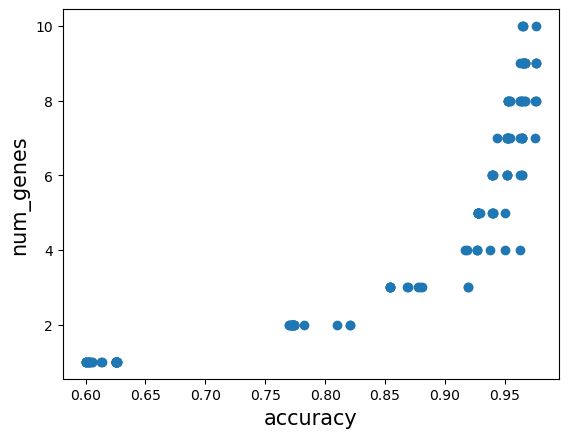

the best one is: accuracy is  0.976388888888889 , num of genes is  8
selected genes are:  [187614.0 27549.0 236282.0 109179.0 1476053.0 45941.0 489535.0 207920.0]
the best one of generation 0 is: accuracy is  0.8944444444444445 , num of genes is  8
the best one of generation 1 is: accuracy is  0.95 , num of genes is  9
the best one of generation 2 is: accuracy is  0.95 , num of genes is  9
the best one of generation 3 is: accuracy is  0.95 , num of genes is  9
the best one of generation 4 is: accuracy is  0.95 , num of genes is  9
the best one of generation 5 is: accuracy is  0.95 , num of genes is  9
the best one of generation 6 is: accuracy is  0.95 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9541666666666666 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9888888888888889 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9888888888888889 , num of genes is  10
the best one of generation 10 is: accuracy is  0.9888888888

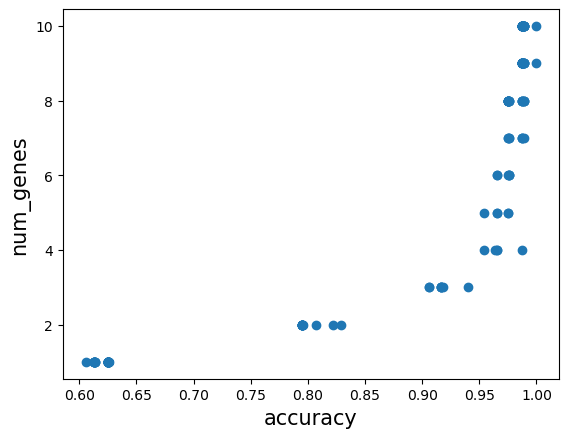

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [786680.0 43338.0 51666.0 288796.0 845419.0 855910.0 40304.0 37553.0
 399532.0]
the best one of generation 0 is: accuracy is  0.8694444444444445 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8805555555555555 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9027777777777779 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9166666666666666 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9166666666666666 , num of genes is  7
the best one of generation 5 is: accuracy is  0.951388888888889 , num of genes is  6
the best one of generation 6 is: accuracy is  0.951388888888889 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9638888888888889 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9638888888888889 , num o

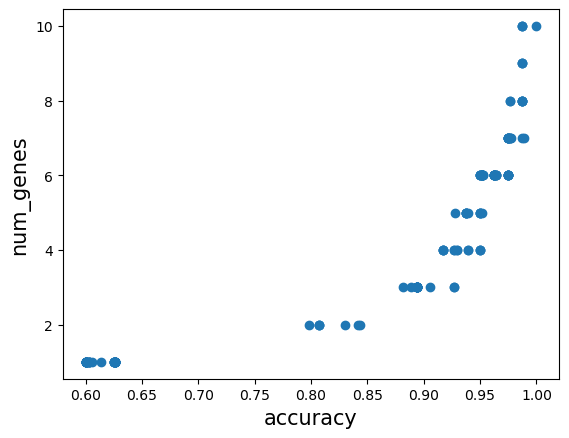

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [949939.0 75644.0 288796.0 37553.0 259579.0 49318.0 530139.0 1435862.0
 853687.0 192569.0]
the best one of generation 0 is: accuracy is  0.8680555555555556 , num of genes is  9
the best one of generation 1 is: accuracy is  0.913888888888889 , num of genes is  10
the best one of generation 2 is: accuracy is  0.913888888888889 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9152777777777779 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9277777777777778 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9277777777777778 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9416666666666667 , num of genes is  6
the best one of generation 7 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9527777777777778 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9625 , num 

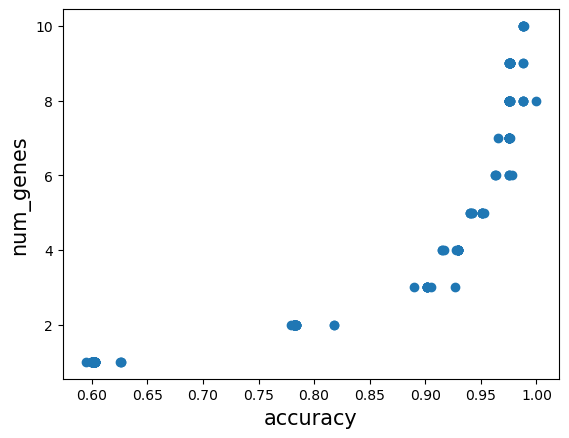

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [769716.0 364510.0 187614.0 486175.0 853687.0 259579.0 796613.0 66965.0]
the best one of generation 0 is: accuracy is  0.9388888888888889 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9388888888888889 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9402777777777779 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9402777777777779 , num of genes is  9
the best one of generation 4 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 5 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 9 is: accuracy is  0.975 , num of genes is  10
the best one of generation 10 is: accurac

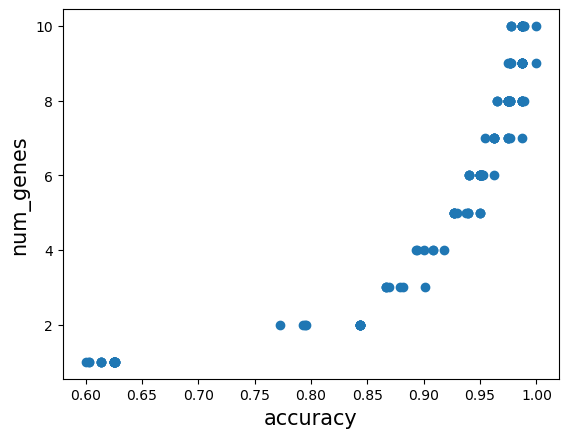

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [742115.0 811843.0 51666.0 1472698.0 782193.0 486175.0 530139.0 877827.0
 300051.0]
the best one of generation 0 is: accuracy is  0.8666666666666666 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8666666666666666 , num of genes is  10
the best one of generation 2 is: accuracy is  0.8916666666666666 , num of genes is  9
the best one of generation 3 is: accuracy is  0.8916666666666666 , num of genes is  9
the best one of generation 4 is: accuracy is  0.8944444444444445 , num of genes is  10
the best one of generation 5 is: accuracy is  0.8944444444444445 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9416666666666667 , num of genes is  8
the best one of generation 9 is: accuracy is  0.941666666666

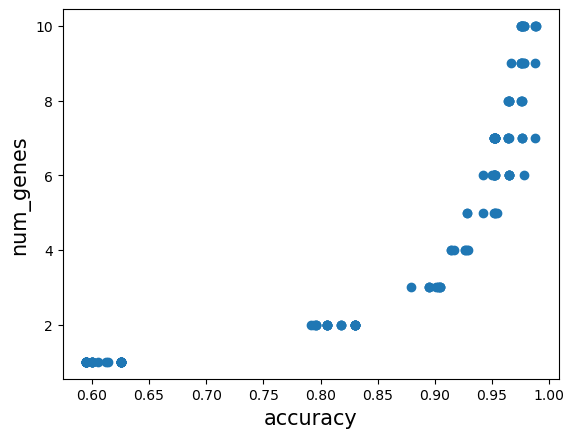

the best one is: accuracy is  0.9888888888888889 , num of genes is  10
selected genes are:  [51666.0 487348.0 809720.0 82297.0 298612.0 309893.0 971367.0 1455641.0
 271102.0 1412412.0]
the best one of generation 0 is: accuracy is  0.8777777777777779 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9152777777777779 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9152777777777779 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9152777777777779 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9152777777777779 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9291666666666666 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9291666666666666 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 9 is: accu

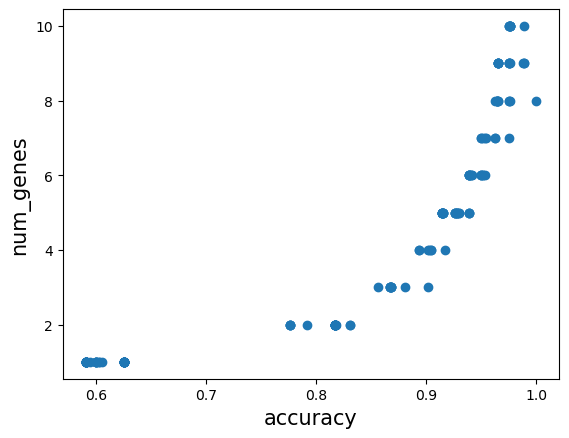

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [42576.0 108377.0 511850.0 1323432.0 853687.0 50887.0 453689.0 471742.0]
the best one of generation 0 is: accuracy is  0.8930555555555555 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8930555555555555 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9305555555555556 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9388888888888889 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9402777777777779 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9527777777777778 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9541666666666666 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9541666666666666 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9888888888888889 , num of genes is  

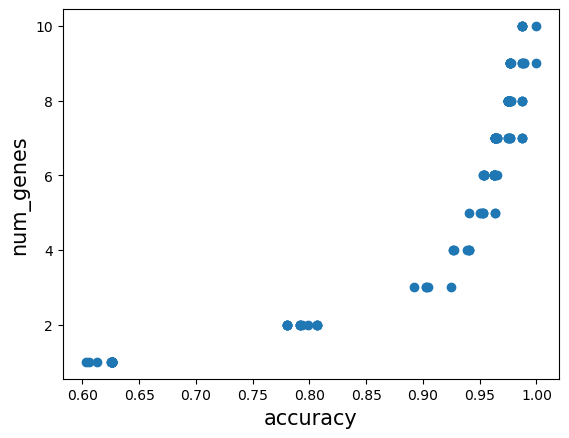

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [486175.0 51666.0 502622.0 357031.0 810504.0 839991.0 450949.0 48614.0
 50117.0]
the best one of generation 0 is: accuracy is  0.9194444444444445 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9194444444444445 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9319444444444445 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9319444444444445 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9319444444444445 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9319444444444445 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9319444444444445 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9416666666666667 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9416666666666667 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9541666666666666 , nu

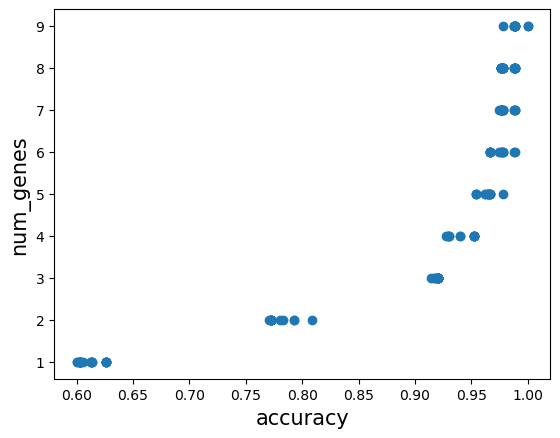

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [50117.0 795321.0 785845.0 21652.0 756405.0 1435339.0 502977.0 1486260.0
 207920.0]
the best one of generation 0 is: accuracy is  0.8694444444444445 , num of genes is  8
the best one of generation 1 is: accuracy is  0.8694444444444445 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9055555555555556 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9055555555555556 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9291666666666666

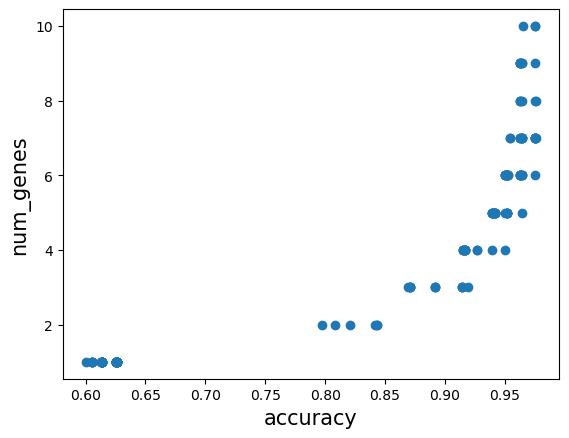

the best one is: accuracy is  0.976388888888889 , num of genes is  7
selected genes are:  [855521.0 282956.0 366341.0 724932.0 853687.0 486175.0 162533.0]
the best one of generation 0 is: accuracy is  0.8666666666666666 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8708333333333332 , num of genes is  9
the best one of generation 2 is: accuracy is  0.8708333333333332 , num of genes is  9
the best one of generation 3 is: accuracy is  0.8930555555555555 , num of genes is  9
the best one of generation 4 is: accuracy is  0.8930555555555555 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9041666666666666 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9152777777777779 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9388888888888889 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9388888888888889 , num of genes is  9
the best one of generation 9 is: accuracy is  0.951388888888889 , num 

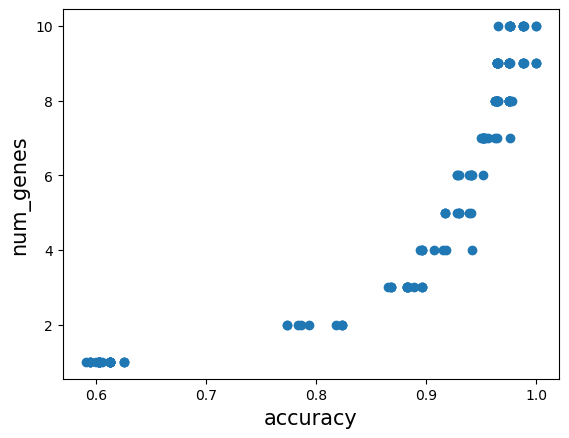

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [855910.0 82297.0 1492104.0 378502.0 877827.0 259579.0 31143.0 855800.0
 223176.0]
the best one of generation 0 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 1 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 2 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 3 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 4 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 5 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  8
the best one of generation 7 is: accuracy is  0.976388888888889 , num of genes is  10
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  10
the best one of generation 9 is: accuracy is  0.976388888888889 , n

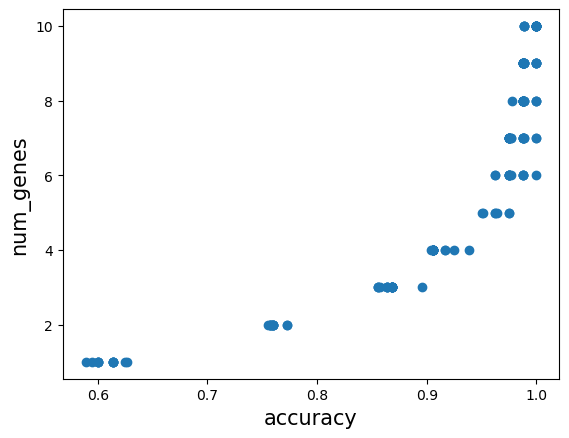

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  [21652.0 43563.0 154472.0 768370.0 51666.0 453689.0]
the best one of generation 0 is: accuracy is  0.8805555555555555 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8805555555555555 , num of genes is  9
the best one of generation 2 is: accuracy is  0.8805555555555555 , num of genes is  9
the best one of generation 3 is: accuracy is  0.8805555555555555 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9180555555555555 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9180555555555555 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9291666666666666 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9291666666666666 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9388888888888889 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9402777777777779 , num of genes is  8
the best on

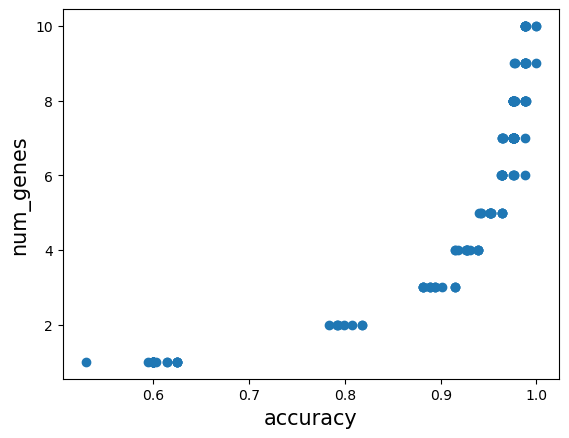

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [486175.0 856650.0 811161.0 767495.0 1412412.0 971367.0 259579.0 769657.0
 530359.0]
the best one of generation 0 is: accuracy is  0.9013888888888889 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9013888888888889 , num of genes is  8
the best one of generation 2 is: accuracy is  0.913888888888889 , num of genes is  7
the best one of generation 3 is: accuracy is  0.925 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9375 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9375 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9375 , num of genes is  8
the best one of generation 7 is: accuracy is  0.95 , num of genes is  8
the best one of generation 8 is: accuracy is  0.951388888888889 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 10 is: accuracy is  0.9625 , 

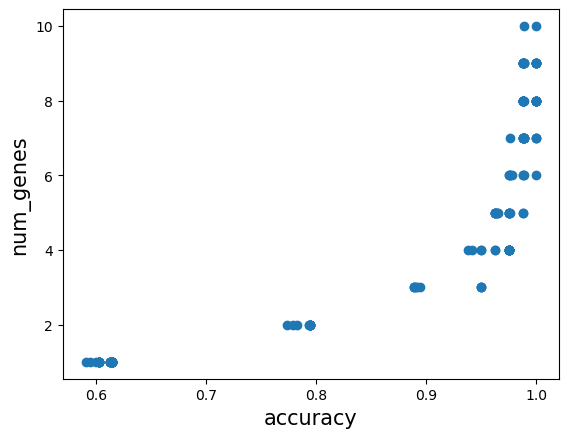

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  [877827.0 486175.0 51666.0 1323448.0 796388.0 25517.0]
the best one of generation 0 is: accuracy is  0.8680555555555556 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8791666666666667 , num of genes is  8
the best one of generation 2 is: accuracy is  0.8805555555555555 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9055555555555556 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9152777777777779 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9180555555555555 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 8 is: accuracy is  0.951388888888889 , num of genes is  10
the best one of generation 9 is: accuracy is  0.975 , num of genes is  8
the best one of generation 10 is: accuracy is

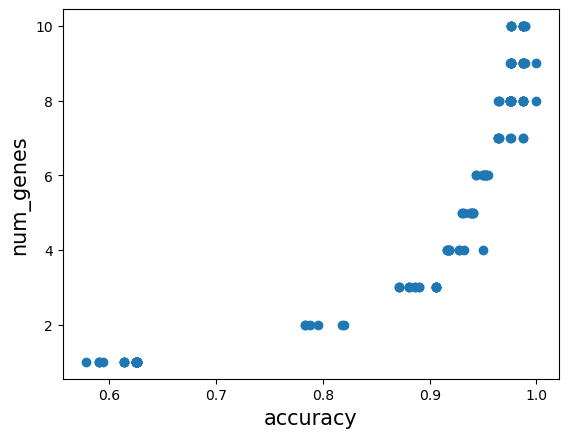

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [288796.0 853687.0 75644.0 1422723.0 50359.0 855800.0 742115.0 345077.0]
the best one of generation 0 is: accuracy is  0.9402777777777779 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9402777777777779 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9402777777777779 , num of genes is  8
the best one of generation 3 is: accuracy is  0.975 , num of genes is  7
the best one of generation 4 is: accuracy is  0.975 , num of genes is  7
the best one of generation 5 is: accuracy is  0.975 , num of genes is  7
the best one of generation 6 is: accuracy is  0.975 , num of genes is  7
the best one of generation 7 is: accuracy is  0.975 , num of genes is  7
the best one of generation 8 is: accuracy is  0.975 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  10
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  8
the b

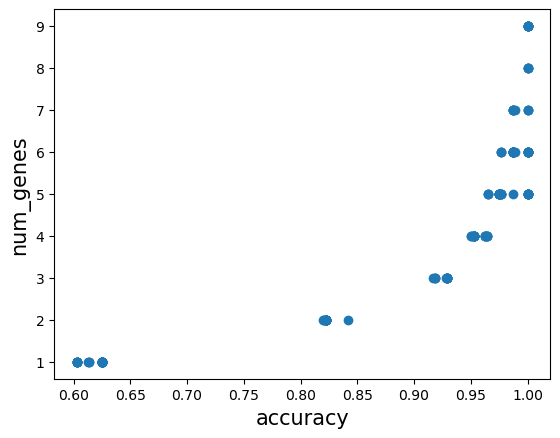

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  [51293.0 809720.0 486175.0 756405.0 436155.0]
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  8
the best one of generation 4 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 5 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 6 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9638888888888889 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9638888888888889 , num of genes is  6
the best one of generation 10 is: accuracy is  0.9638888888888889 , n

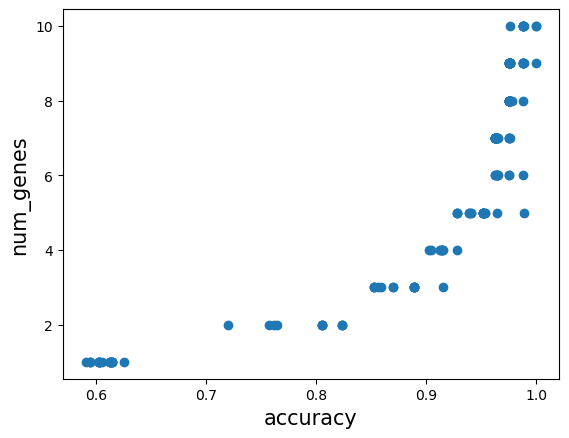

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [856650.0 489553.0 43241.0 42576.0 742115.0 1474955.0 288796.0 461327.0
 49410.0]
the best one of generation 0 is: accuracy is  0.9180555555555555 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9180555555555555 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9180555555555555 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9527777777777778 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9527777777777778 , num of genes is  9
the best one of generation 5 is: accuracy is  0.976388888888889 , num of genes is  10
the best one of generation 6 is: accuracy is  0.976388888888889 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9777777777777779 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9777777777777779 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9777777777777779 , 

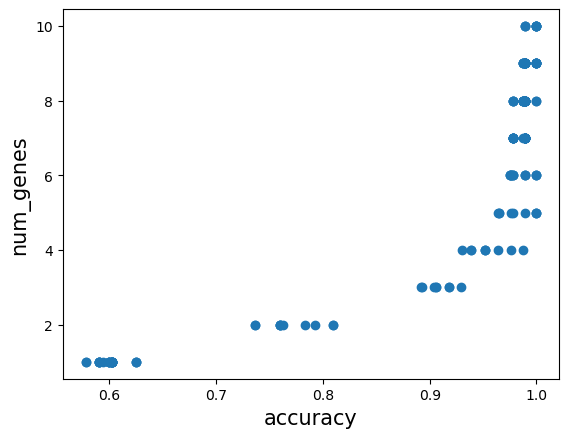

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  [486175.0 756405.0 344272.0 877827.0 345232.0]
the best one of generation 0 is: accuracy is  0.8652777777777778 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8791666666666667 , num of genes is  8
the best one of generation 2 is: accuracy is  0.8791666666666667 , num of genes is  8
the best one of generation 3 is: accuracy is  0.8791666666666667 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9291666666666666 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9291666666666666 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9291666666666666 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9291666666666666 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9291666666666666 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9402777777777779 , num of genes is  10
the best one of

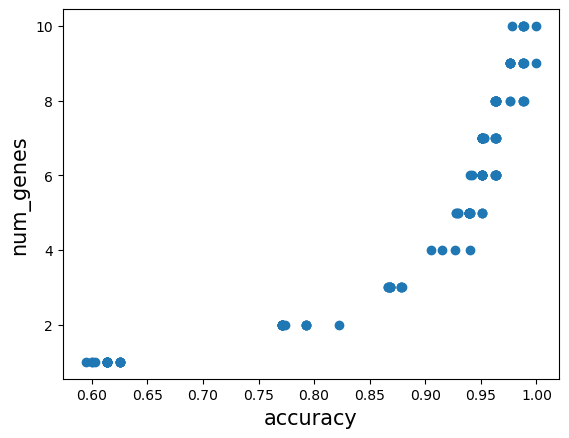

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [50117.0 949939.0 259579.0 28410.0 797048.0 756401.0 810504.0 109179.0
 502977.0]
the best one of generation 0 is: accuracy is  0.8805555555555555 , num of genes is  8
the best one of generation 1 is: accuracy is  0.8805555555555555 , num of genes is  8
the best one of generation 2 is: accuracy is  0.8805555555555555 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9166666666666666 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9277777777777778 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9277777777777778 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9277777777777778 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9402777777777779 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9402777777777779 , num of genes is  6
the best one of generation 9 is: accuracy is  0.951388888888889 , nu

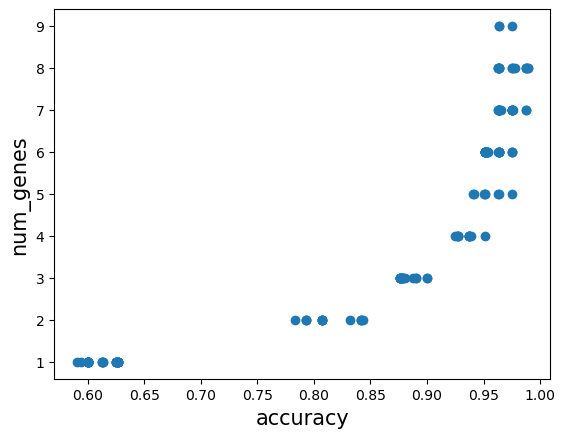

the best one is: accuracy is  0.9888888888888889 , num of genes is  8
selected genes are:  [884894.0 756405.0 878815.0 853687.0 742115.0 502977.0 39285.0 839991.0]
the best one of generation 0 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9166666666666666 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9180555555555555 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9263888888888889 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9291666666666666 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9527777777777778 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  8


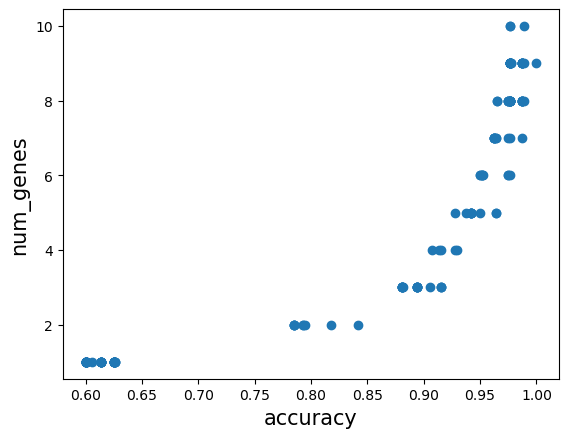

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [877827.0 40304.0 488276.0 45941.0 50117.0 1492104.0 744940.0 24145.0
 51666.0]
the best one of generation 0 is: accuracy is  0.9027777777777779 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9277777777777778 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9277777777777778 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9277777777777778 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9291666666666666 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9291666666666666 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9416666666666667 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9416666666666667 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9638888888888889 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9652777777777779 , num

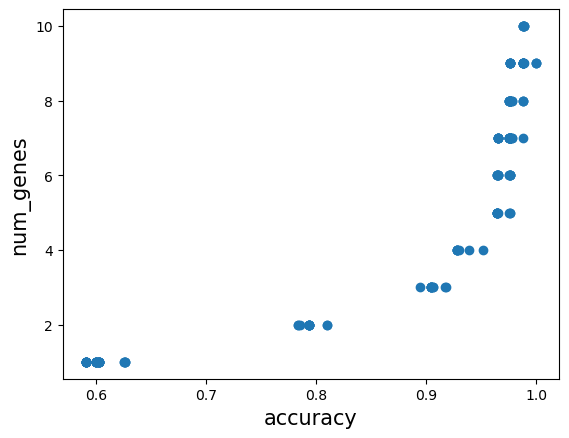

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [38471.0 271102.0 51666.0 43338.0 248631.0 824552.0 756600.0 506032.0
 756549.0]
the best one of generation 0 is: accuracy is  0.8958333333333333 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8958333333333333 , num of genes is  9
the best one of generation 2 is: accuracy is  0.8958333333333333 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9416666666666667 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9416666666666667 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9416666666666667 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9541666666666666 , nu

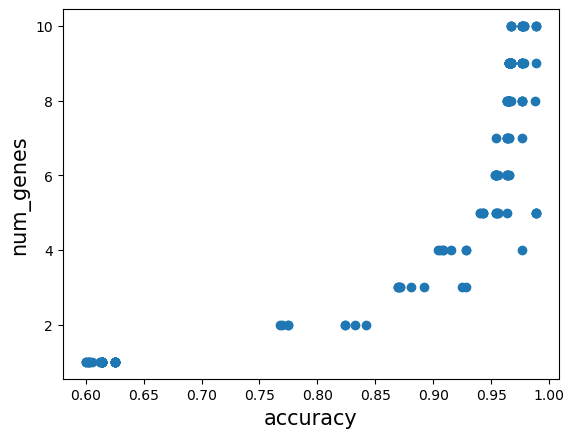

the best one is: accuracy is  0.9888888888888889 , num of genes is  5
selected genes are:  [34355.0 486175.0 366341.0 811161.0 207920.0]
the best one of generation 0 is: accuracy is  0.8805555555555555 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8805555555555555 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9041666666666666 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9152777777777779 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9152777777777779 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9152777777777779 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9263888888888889 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9277777777777778 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9305555555555556 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9305555555555556 , num of genes is  

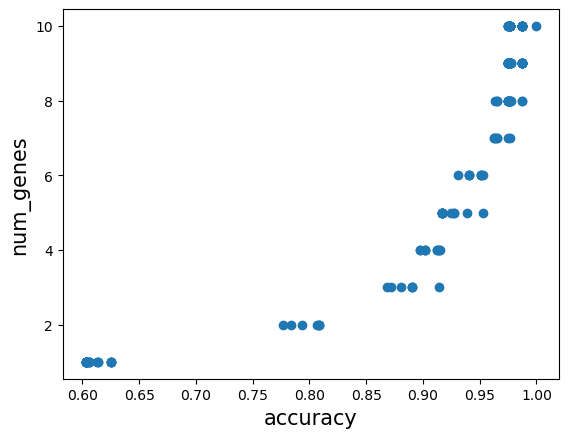

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [51666.0 1471829.0 279378.0 486175.0 754085.0 810504.0 154790.0 453689.0
 811843.0 23132.0]
the best one of generation 0 is: accuracy is  0.9055555555555556 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9291666666666666 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9402777777777779 , num of genes is  10
the best one of generation 8 is: accuracy is  0.951388888888889 , num of genes is  9
the best one of generation 9 is: accuracy is  0.955

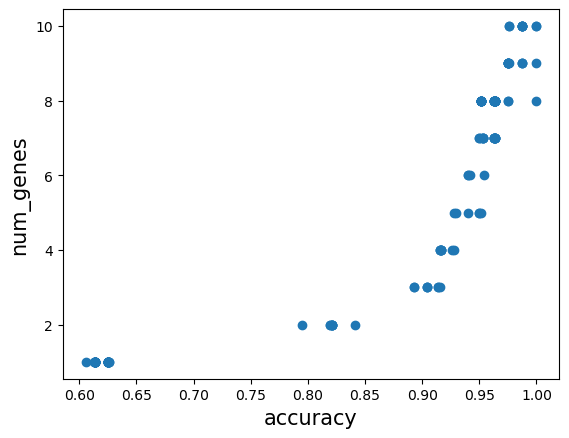

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [187614.0 43241.0 45941.0 275180.0 451907.0 109179.0 770452.0 725672.0]


In [9]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=10,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.975 , num of genes is  10
the best one of generation 1 is: accuracy is  0.975 , num of genes is  10
the best one of generation 2 is: accuracy is  0.975 , num of genes is  10
the best one of generation 3 is: accuracy is  0.975 , num of genes is  10
the best one of generation 4 is: accuracy is  0.975 , num of genes is  10
the best one of generation 5 is: accuracy is  0.975 , num of genes is  10
the best one of generation 6 is: accuracy is  0.976388888888889 , num of genes is  12
the best one of generation 7 is: accuracy is  0.976388888888889 , num of genes is  12
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  12
the best one of generation 9 is: accuracy is  0.9888888888888889 , num of genes is  11
the best one of generation 10 is: accuracy is  0.9888888888888889 , num of genes is  11
the best one of generation 11 is: accuracy is  0.9888888888888889 , num of genes is  11
the best one of generation 12 is: a

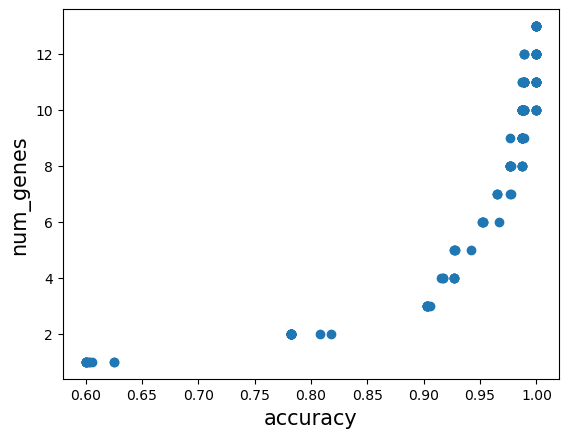

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [75644.0 491727.0 34945.0 432194.0 51666.0 1468310.0 32493.0 31143.0
 43338.0 756533.0]
the best one of generation 0 is: accuracy is  0.9388888888888889 , num of genes is  14
the best one of generation 1 is: accuracy is  0.951388888888889 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9527777777777778 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9638888888888889 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9638888888888889 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9652777777777779 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9666666666666666 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9888888888888889 , num of genes is  13
the best one of generation 8 is: accuracy is  0.9888888888888889 , num of genes is  13
the best one of generation 9 is: accuracy is  1.0 , n

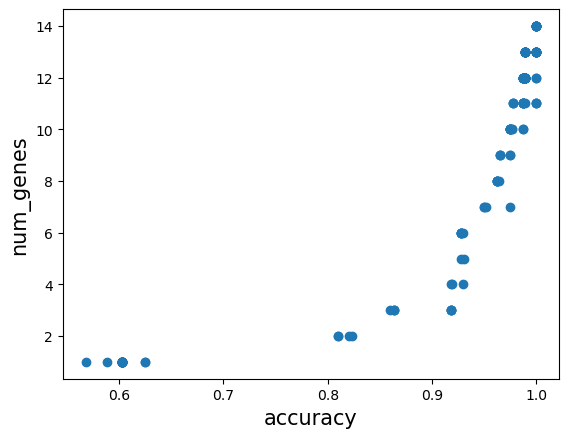

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [248631.0 154600.0 853687.0 53092.0 50117.0 489519.0 506548.0 856650.0
 810753.0 265102.0 49591.0]
the best one of generation 0 is: accuracy is  0.9277777777777778 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9277777777777778 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9652777777777779 , num of genes is  15
the best one of generation 4 is: accuracy is  0.9652777777777779 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9652777777777779 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9652777777777779 , num of genes is  14
the best one of generation 7 is: accuracy is  1.0 , num of genes is  15
the best one of generation 8 is: accuracy is  1.0 , num of genes is  15
the best one of generation 9 is: accuracy is  1.0 , num of genes is  15
the best one o

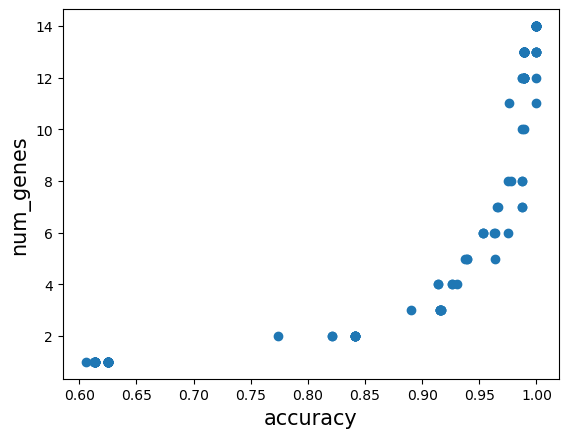

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [366341.0 39285.0 756405.0 853687.0 141818.0 51740.0 452374.0 39722.0
 187614.0 162775.0 323474.0]
the best one of generation 0 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 1 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 2 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 3 is: accuracy is  0.975 , num of genes is  14
the best one of generation 4 is: accuracy is  0.975 , num of genes is  14
the best one of generation 5 is: accuracy is  0.975 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  15
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  15
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9888888888888889 , num of genes is  15
the best one of generation 10 is

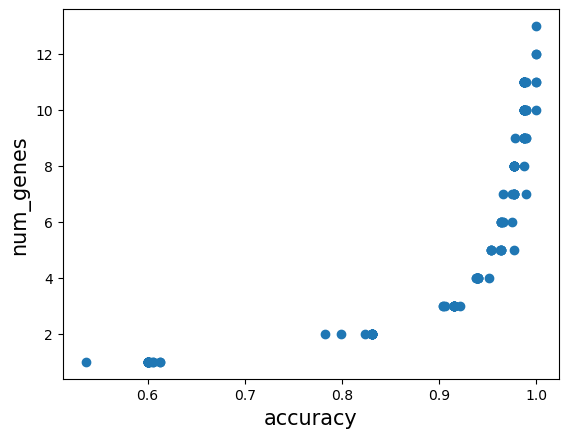

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [742115.0 377314.0 1323432.0 971367.0 45941.0 1468310.0 511850.0 768370.0
 506032.0 884867.0]
the best one of generation 0 is: accuracy is  0.9041666666666666 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9041666666666666 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9152777777777779 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9291666666666666 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9291666666666666 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9388888888888889 , num of genes is  12
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 8 is: accuracy is  0.975 , num of genes is  15
the best one of generation 9 is: accuracy is  0.975 , num of genes is  15
the best o

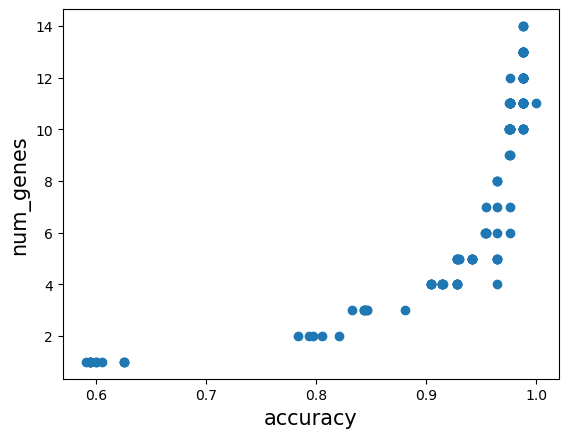

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [42739.0 486186.0 1476053.0 487761.0 627306.0 845419.0 814353.0 21652.0
 729964.0 345430.0 154472.0]
the best one of generation 0 is: accuracy is  0.9166666666666666 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9166666666666666 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9277777777777778 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9541666666666666 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9541666666666666 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9541666666666666 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 8 is: accuracy is  0.975 , num of genes is  12
the best one of generation 9 is: accuracy is  0.975 , num of genes is  12
th

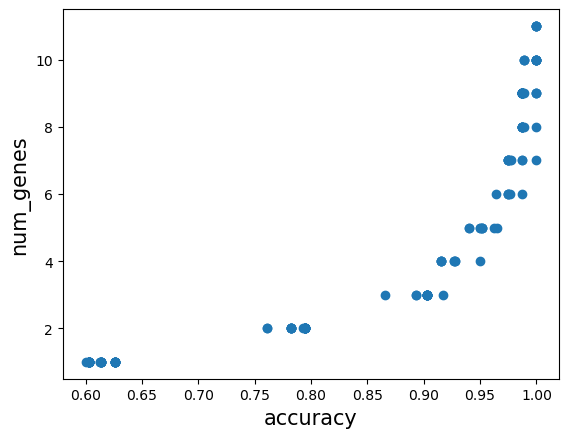

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  [853687.0 271102.0 50117.0 259579.0 489506.0 1412412.0 279790.0]
the best one of generation 0 is: accuracy is  0.9166666666666666 , num of genes is  14
the best one of generation 1 is: accuracy is  0.9166666666666666 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9263888888888889 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9319444444444445 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9319444444444445 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9402777777777779 , num of genes is  15
the best one of generation 6 is: accuracy is  0.9430555555555555 , num of genes is  15
the best one of generation 7 is: accuracy is  0.9541666666666666 , num of genes is  15
the best one of generation 8 is: accuracy is  0.9652777777777779 , num of genes is  12
the best one of generation 9 is: accuracy is  0.9652777777777779 , num of ge

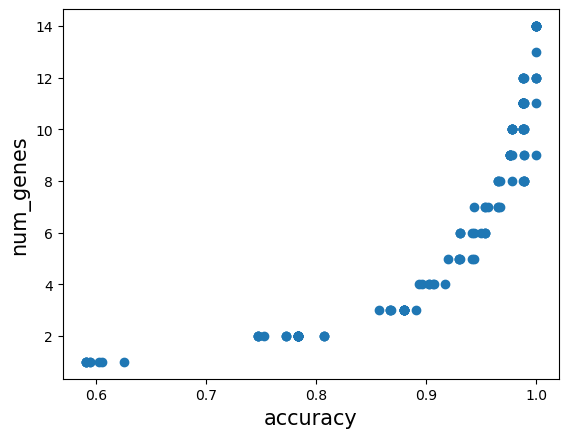

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [756533.0 43338.0 754085.0 187614.0 415102.0 29054.0 210687.0 266312.0
 291756.0]
the best one of generation 0 is: accuracy is  0.9041666666666666 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9041666666666666 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9041666666666666 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9166666666666666 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9277777777777778 , num of genes is  12
the best one of generation 5 is: accuracy is  0.9291666666666666 , num of genes is  12
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9527777777777778 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9652777777777779 , num of genes is  13
the best one of generation 9 is: accuracy is  0.96527777777

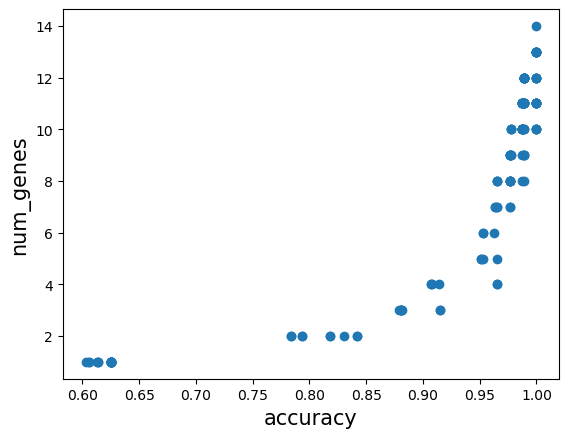

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [856650.0 511850.0 768644.0 366341.0 729964.0 1471829.0 282956.0 291756.0
 786680.0 486175.0]
the best one of generation 0 is: accuracy is  0.9291666666666666 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9291666666666666 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9291666666666666 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9291666666666666 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9388888888888889 , num of genes is  15
the best one of generation 5 is: accuracy is  0.9527777777777778 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9638888888888889 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  13
the best one of generation 8 is: accuracy is  0.9652777777777779 , num of genes is  12
the best one of generation 9 is: accuracy is  

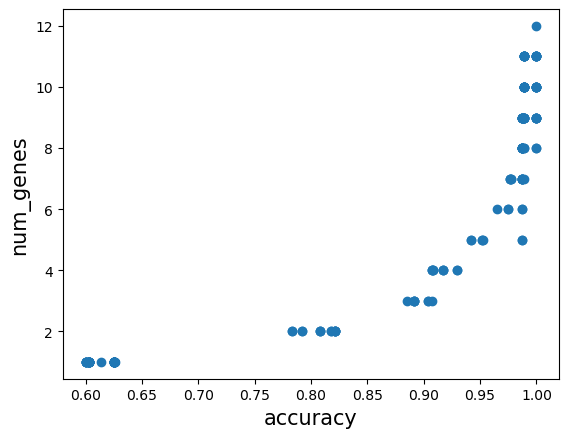

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [298965.0 486175.0 44255.0 768370.0 39285.0 248631.0 882522.0 502355.0]
the best one of generation 0 is: accuracy is  0.9388888888888889 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  15
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  15
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  15
the best one of ge

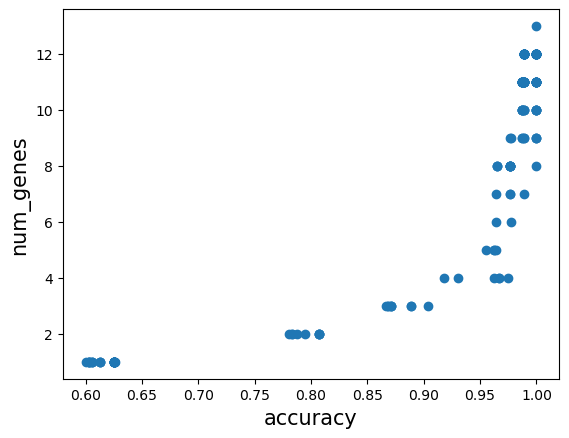

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [877827.0 431501.0 50117.0 489553.0 626206.0 771220.0 1472719.0 120108.0]
the best one of generation 0 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 1 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9638888888888889 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9638888888888889 , num of genes is  15
the best one of generation 4 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9638888888888889 , num of genes is  7
the best one of generation 9 is: accuracy is  0.976388888888889 , num o

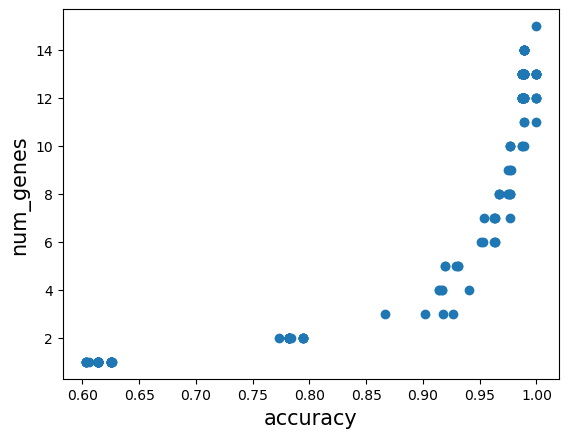

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [811843.0 884766.0 970591.0 769657.0 21652.0 811585.0 1323432.0 809910.0
 511850.0 1455641.0 884894.0]
the best one of generation 0 is: accuracy is  0.9291666666666666 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9291666666666666 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9541666666666666 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9541666666666666 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9541666666666666 , num of genes is  12
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  11
the best one of generation 6 is: accuracy is  0.9666666666666666 , num of genes is  14
the best one of generation 7 is: accuracy is  0.975 , num of genes is  14
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  13
the best one of generation 9 is: accuracy is  0.977777777777777

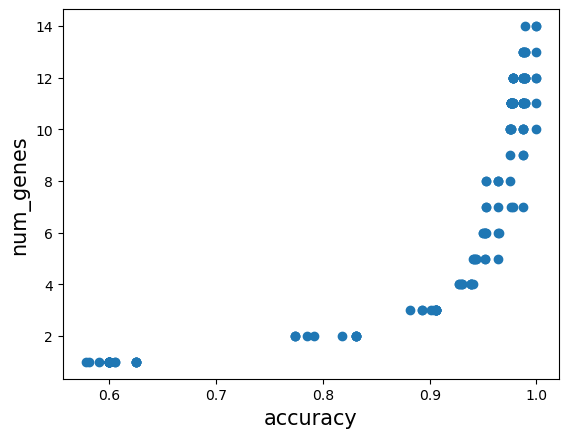

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [154472.0 1473274.0 1472753.0 506032.0 309893.0 309288.0 187614.0 45464.0
 824025.0 878815.0]
the best one of generation 0 is: accuracy is  0.9027777777777779 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9152777777777779 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9152777777777779 , num of genes is  11
the best one of generation 3 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 4 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 5 is: accuracy is  0.951388888888889 , num of genes is  15
the best one of generation 6 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9541666666666666 , num of genes is  8
the best one of generation 9 is: accuracy is  0.95416

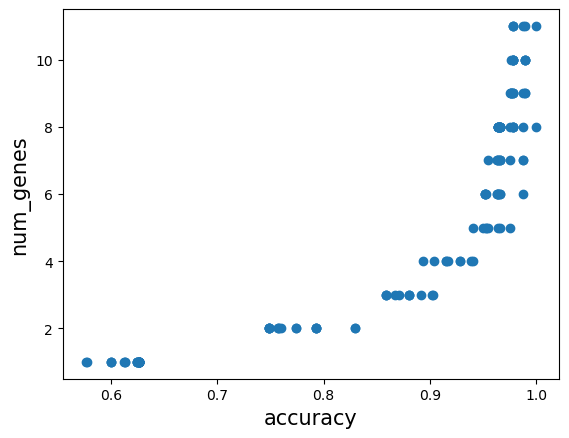

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  [45941.0 187614.0 756405.0 248631.0 25807.0 811013.0 223176.0 756490.0]
the best one of generation 0 is: accuracy is  0.9416666666666667 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9416666666666667 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9416666666666667 , num of genes is  15
the best one of generation 3 is: accuracy is  0.951388888888889 , num of genes is  14
the best one of generation 4 is: accuracy is  0.951388888888889 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9638888888888889 , num of genes is  15
the best one of generation 6 is: accuracy is  0.9638888888888889 , num of genes is  13
the best one of generation 7 is: accuracy is  0.976388888888889 , num of genes is  15
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  13
the best one of generation 9 is: accuracy is  0.976388888888889 , num of 

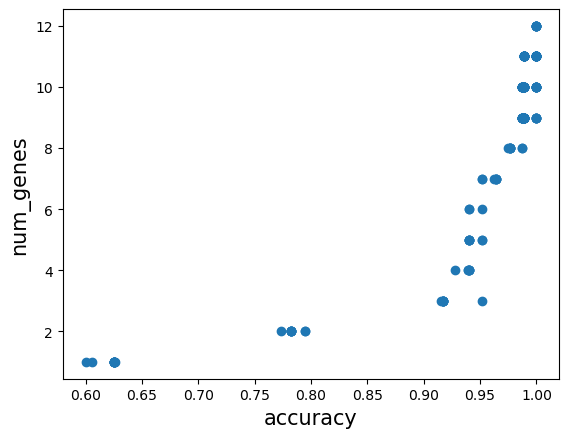

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [272183.0 50117.0 853687.0 450777.0 809720.0 259973.0 842825.0 22293.0
 25499.0]
the best one of generation 0 is: accuracy is  0.9208333333333332 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9263888888888889 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9263888888888889 , num of genes is  11
the best one of generation 3 is: accuracy is  0.9263888888888889 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9388888888888889 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9402777777777779 , num of genes is  12
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 8 is: accuracy is  0.9527777777777778 , num of genes is  14
the best one of generation 9 is: accuracy is  0.975 , num of

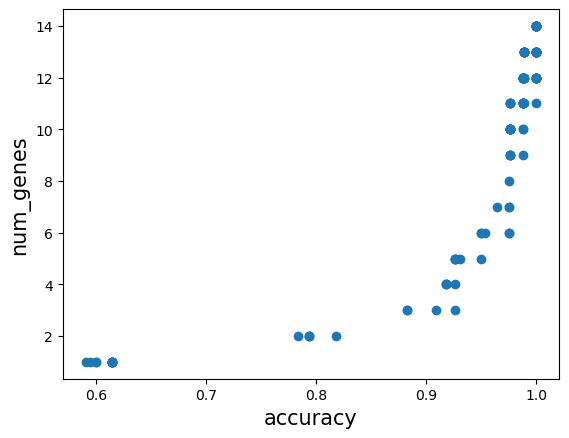

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [809720.0 1475797.0 288796.0 845419.0 814444.0 1435862.0 45941.0 323577.0
 502977.0 811161.0 853906.0]
the best one of generation 0 is: accuracy is  0.9013888888888889 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9152777777777779 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9388888888888889 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9527777777777778 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9527777777777778 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9875 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  14
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  14
the best o

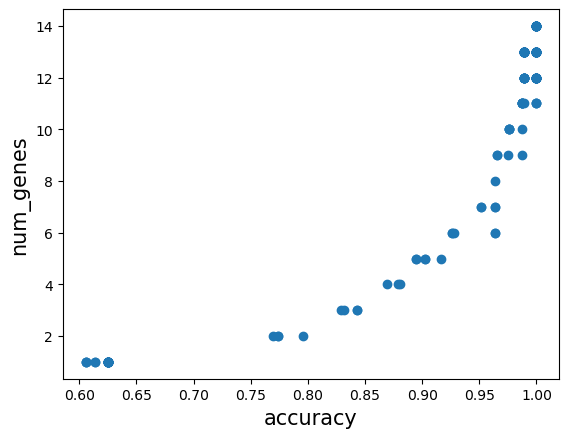

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [362926.0 486175.0 207920.0 395708.0 214965.0 259973.0 450711.0 34357.0
 23132.0 51666.0 70332.0]
the best one of generation 0 is: accuracy is  0.9402777777777779 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9402777777777779 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9402777777777779 , num of genes is  12
the best one of generation 3 is: accuracy is  0.951388888888889 , num of genes is  14
the best one of generation 4 is: accuracy is  0.951388888888889 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9527777777777778 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9652777777777779 , num of genes is  14
the best one of generation 9 is: accuracy is

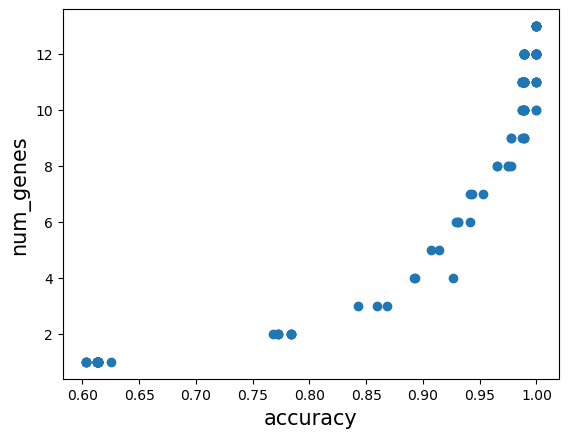

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [1472698.0 42576.0 83549.0 530139.0 1412412.0 897768.0 856650.0 797048.0
 278501.0 141314.0]
the best one of generation 0 is: accuracy is  0.9277777777777778 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9277777777777778 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9291666666666666 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9402777777777779 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9402777777777779 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9638888888888889 , num of genes is  12
the best one of generation 6 is: accuracy is  0.9638888888888889 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  12
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  11
the best one of generation 9 is: accuracy is  0.

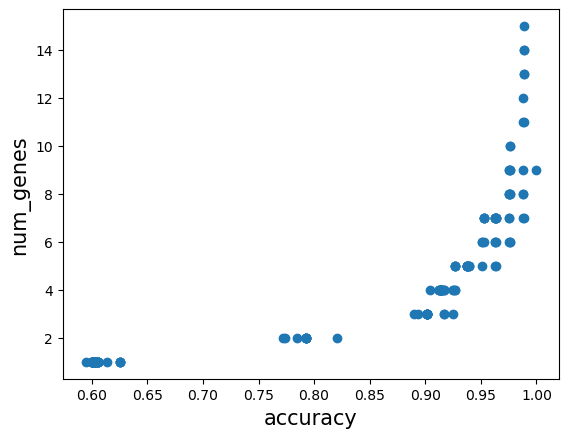

the best one is: accuracy is  1.0 , num of genes is  9
selected genes are:  [120108.0 490947.0 856650.0 288796.0 855061.0 853687.0 1404396.0 1435862.0
 22918.0]
the best one of generation 0 is: accuracy is  0.9402777777777779 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9402777777777779 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9402777777777779 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9402777777777779 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 5 is: accuracy is  0.9527777777777778 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9652777777777779 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9652777777777779 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9666666666666666 , num of genes is  12
the best one of generation 9 is: accuracy is  0.96666666

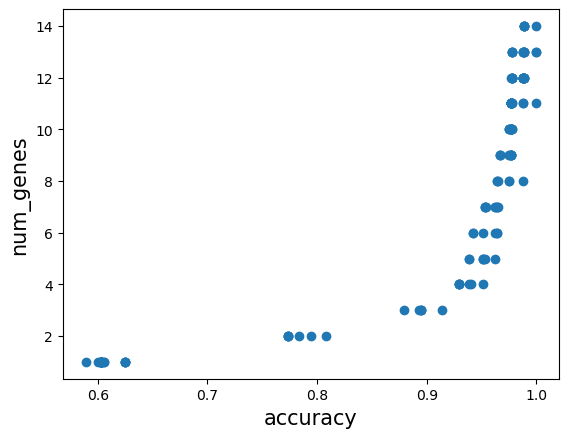

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [432194.0 32493.0 450777.0 1323432.0 21652.0 856650.0 230385.0 22293.0
 769552.0 1455641.0 323603.0]
the best one of generation 0 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 1 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 3 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 5 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9527777777777778 , num of genes is  10
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  10
the best one of generation 9 is: accurac

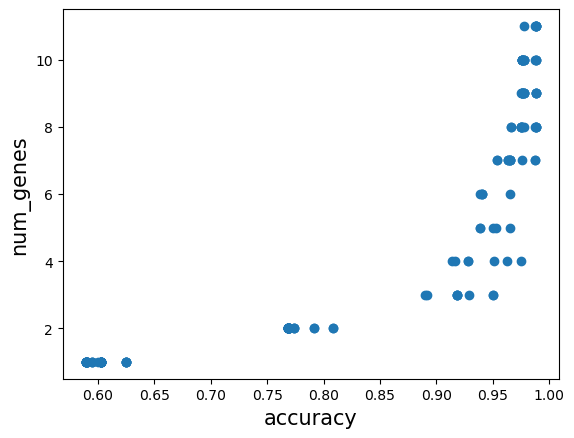

the best one is: accuracy is  0.9888888888888889 , num of genes is  8
selected genes are:  [882510.0 840708.0 811585.0 877827.0 770452.0 742115.0 1323448.0 82131.0]
the best one of generation 0 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9416666666666667 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  15
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 8 is: accuracy is  0.9652777777777779 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9875

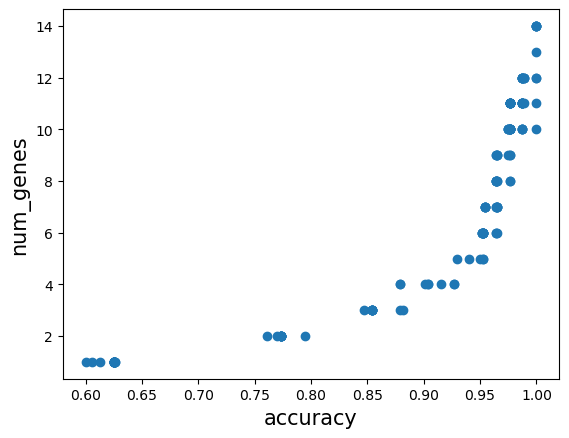

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [1412503.0 45941.0 489506.0 878815.0 839991.0 626358.0 362926.0 365515.0
 43241.0 768370.0]
the best one of generation 0 is: accuracy is  0.9152777777777779 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9263888888888889 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9277777777777778 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9277777777777778 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9402777777777779 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 7 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 8 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 9 is: accuracy is  0.

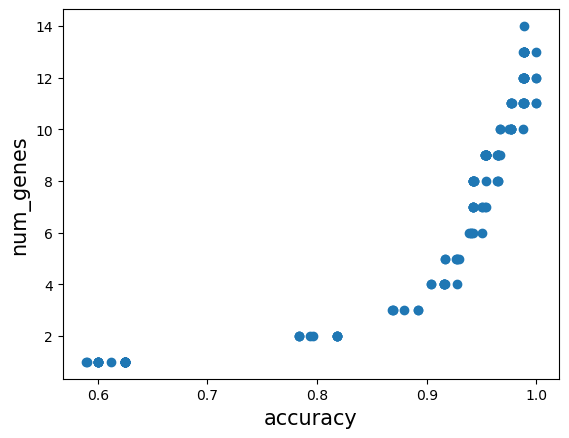

the best one is: accuracy is  1.0 , num of genes is  11
selected genes are:  [22260.0 713263.0 770027.0 323577.0 769959.0 810504.0 824025.0 299388.0
 1461138.0 814444.0 626206.0]
the best one of generation 0 is: accuracy is  0.9527777777777778 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9527777777777778 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9527777777777778 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9527777777777778 , num of genes is  15
the best one of generation 4 is: accuracy is  0.9638888888888889 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9638888888888889 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9652777777777779 , num of genes is  15
the best one of generation 7 is: accuracy is  0.9652777777777779 , num of genes is  15
the best one of generation 8 is: accuracy is  0.976388888888889 , num of genes is  14
the best one of generation 9 is: accura

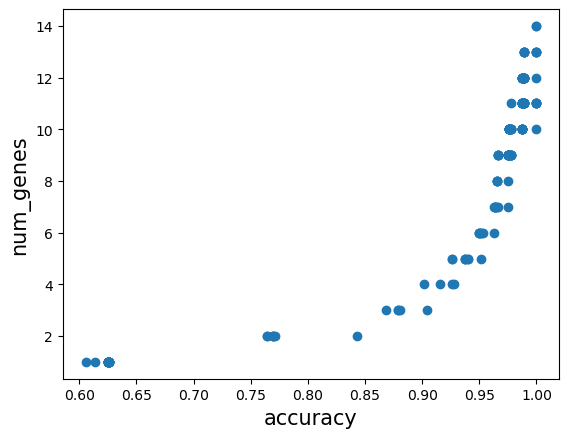

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [1422723.0 756533.0 75644.0 nan 754085.0 284882.0 45941.0 1472698.0
 853570.0 183440.0]
the best one of generation 0 is: accuracy is  0.95 , num of genes is  14
the best one of generation 1 is: accuracy is  0.95 , num of genes is  14
the best one of generation 2 is: accuracy is  0.95 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 6 is: accuracy is  0.975 , num of genes is  14
the best one of generation 7 is: accuracy is  0.975 , num of genes is  14
the best one of generation 8 is: accuracy is  0.975 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9777777777777779 , num of genes is  15
the best one of generation 10 is: accuracy is  0.9777777777777779 , num of genes i

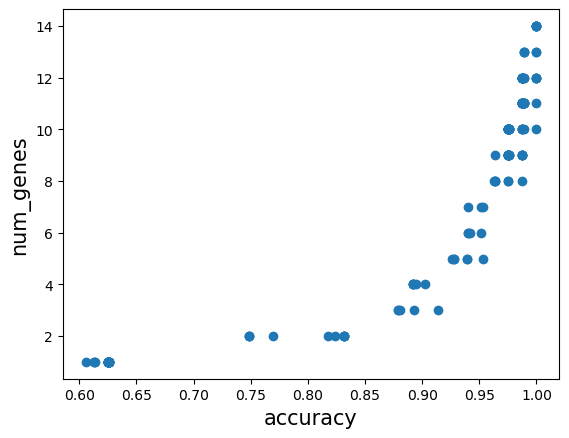

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  [39285.0 769716.0 782193.0 345077.0 754649.0 362926.0 43563.0 288796.0
 1435339.0 774754.0]
the best one of generation 0 is: accuracy is  0.9166666666666666 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9166666666666666 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9166666666666666 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9305555555555556 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9305555555555556 , num of genes is  12
the best one of generation 5 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 6 is: accuracy is  0.9416666666666667 , num of genes is  11
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9638888888888889 , num of genes is  8
the best one of generation 9 is: accuracy is  0.96388888888888

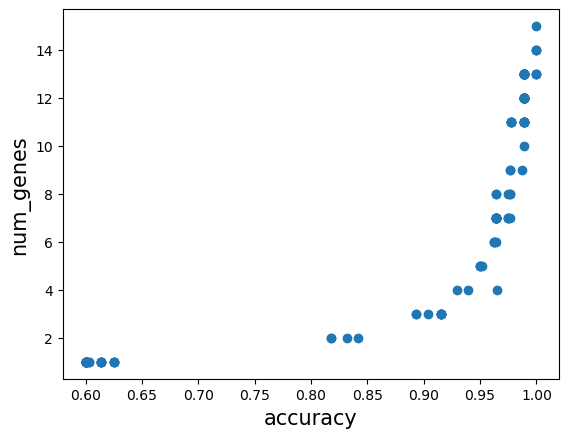

the best one is: accuracy is  1.0 , num of genes is  13
selected genes are:  [745496.0 378488.0 782193.0 288796.0 25499.0 811585.0 809910.0 40304.0
 21652.0 365515.0 1469230.0 853687.0 271748.0]


In [6]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=15,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.7819444444444444 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8083333333333332 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8527777777777779 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8597222222222222 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9152777777777779 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9152777777777779 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9152777777777779 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9152777777777779 , num of genes is  4
the best one of generation 11 is: accuracy is  0.9152

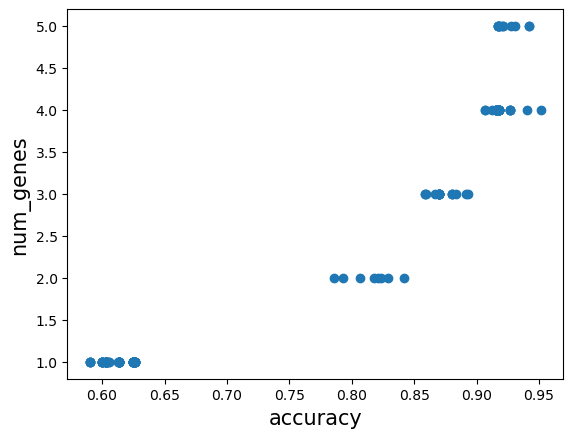

the best one is: accuracy is  0.951388888888889 , num of genes is  4
selected genes are:  [109179.0 50117.0 884867.0 450777.0]
the best one of generation 0 is: accuracy is  0.8347222222222221 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8347222222222221 , num of genes is  3
the best one of generation 2 is: accuracy is  0.861111111111111 , num of genes is  3
the best one of generation 3 is: accuracy is  0.861111111111111 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8805555555555555 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8805555555555555 , num of genes is  3
the best one of generation 6 is: accuracy is  0.8805555555555555 , num of genes is  3
the best one of generation 7 is: accuracy is  0.8805555555555555 , num of genes is  3
the best one of generation 8 is: accuracy is  0.8805555555555555 , num of genes is  3
the best one of generation 9 is: accuracy is  0.8805555555555555 , num of genes is  3
the best one of

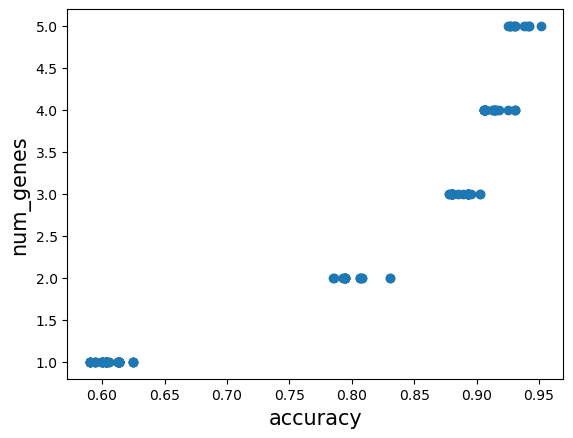

the best one is: accuracy is  0.951388888888889 , num of genes is  5
selected genes are:  [50117.0 810504.0 853687.0 51666.0 278501.0]
the best one of generation 0 is: accuracy is  0.8055555555555556 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8055555555555556 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8097222222222221 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8194444444444444 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8305555555555555 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8333333333333333 , num of genes is  4
the best one of generation 6 is: accuracy is  0.8569444444444445 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9166666666666666 , num of genes is  5
the b

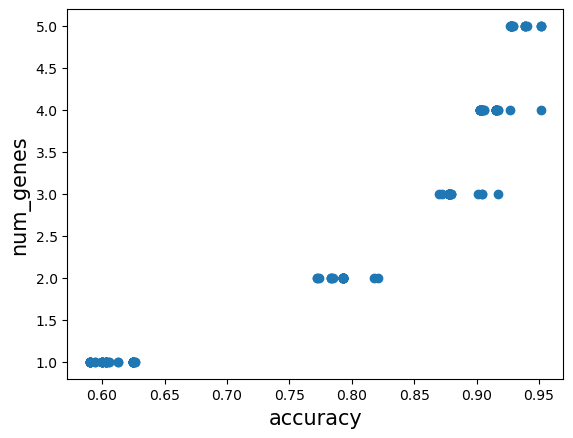

the best one is: accuracy is  0.951388888888889 , num of genes is  4
selected genes are:  [259579.0 43338.0 345232.0 50117.0]
the best one of generation 0 is: accuracy is  0.7513888888888889 , num of genes is  5
the best one of generation 1 is: accuracy is  0.7694444444444445 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8583333333333332 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8583333333333332 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8583333333333332 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8583333333333332 , num of genes is  3
the best one of generation 6 is: accuracy is  0.8583333333333332 , num of genes is  3
the best one of generation 7 is: accuracy is  0.8583333333333332 , num of genes is  3
the best one of generation 8 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 9 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one o

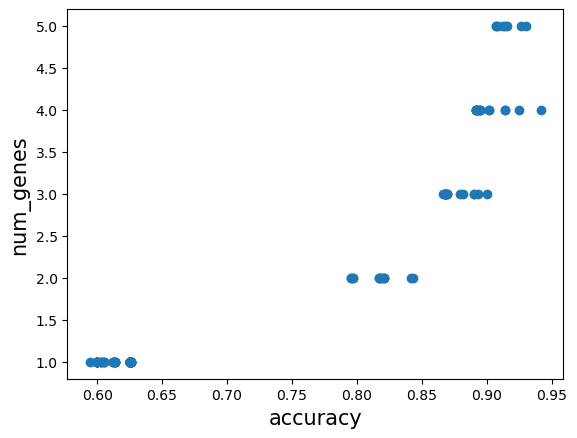

the best one is: accuracy is  0.9416666666666667 , num of genes is  4
selected genes are:  [345077.0 323577.0 50117.0 109179.0]
the best one of generation 0 is: accuracy is  0.8708333333333332 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8708333333333332 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8708333333333332 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8708333333333332 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 9 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one

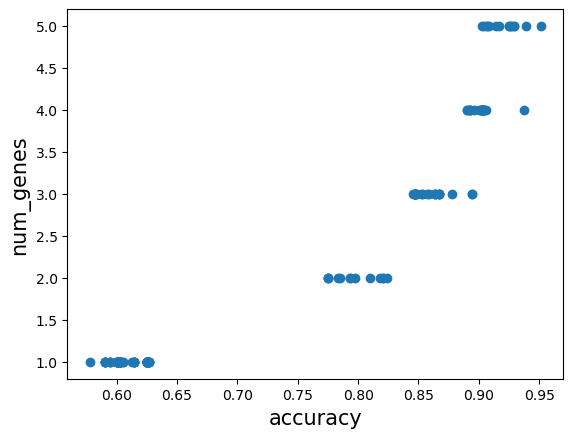

the best one is: accuracy is  0.951388888888889 , num of genes is  5
selected genes are:  [897768.0 453689.0 877827.0 768644.0 42993.0]
the best one of generation 0 is: accuracy is  0.8097222222222221 , num of genes is  2
the best one of generation 1 is: accuracy is  0.9402777777777779 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9402777777777779 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9402777777777779 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9402777777777779 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 10 is: accuracy is  0.9625 , num of g

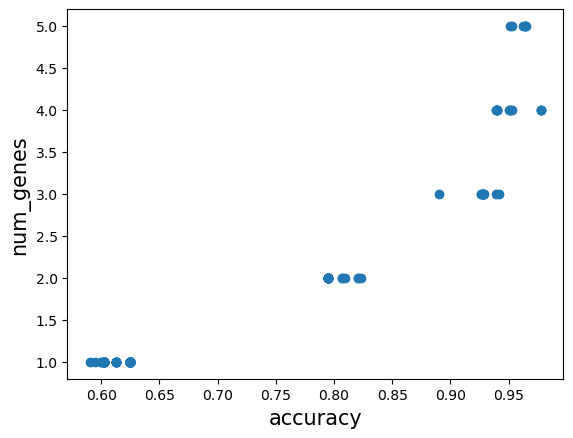

the best one is: accuracy is  0.9777777777777779 , num of genes is  4
selected genes are:  [626358.0 756405.0 877827.0 39285.0]
the best one of generation 0 is: accuracy is  0.7916666666666666 , num of genes is  5
the best one of generation 1 is: accuracy is  0.7916666666666666 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8166666666666667 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8569444444444445 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8583333333333332 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 6 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 7 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 8 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 9 is: accuracy is  0.8819444444444444 , num of genes is  3
the best one

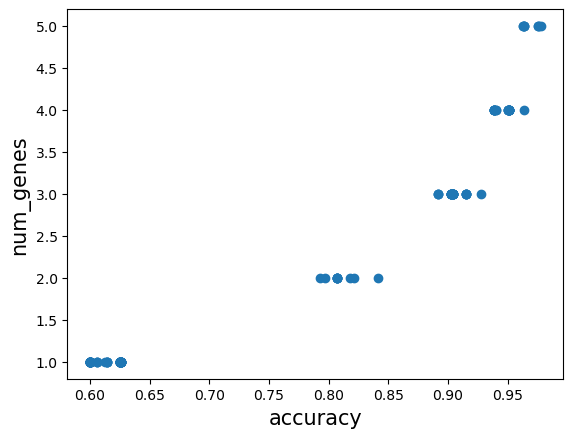

the best one is: accuracy is  0.9777777777777779 , num of genes is  5
selected genes are:  [154472.0 44255.0 853687.0 756405.0 39285.0]
the best one of generation 0 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8930555555555555 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9055555555555556 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9055555555555556 , num of genes is  4
the 

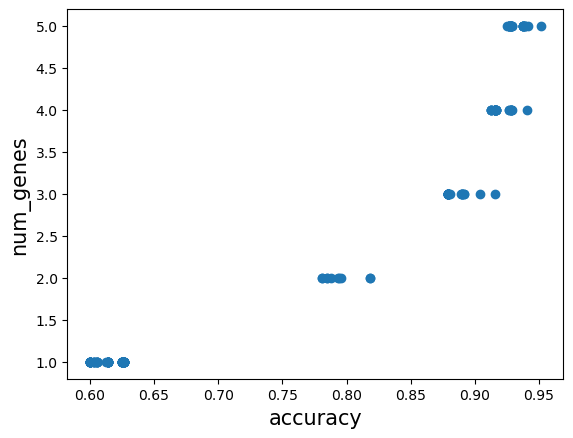

the best one is: accuracy is  0.951388888888889 , num of genes is  5
selected genes are:  [450777.0 154600.0 729964.0 1323432.0 271102.0]
the best one of generation 0 is: accuracy is  0.8055555555555556 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8097222222222221 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8097222222222221 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8777777777777779 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8777777777777779 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8777777777777779 , num of genes is  3
the best one of generation 6 is: accuracy is  0.8777777777777779 , num of genes is  3
the best one of generation 7 is: accuracy is  0.8777777777777779 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9055555555555556 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9055555555555556 , num of genes is  5
th

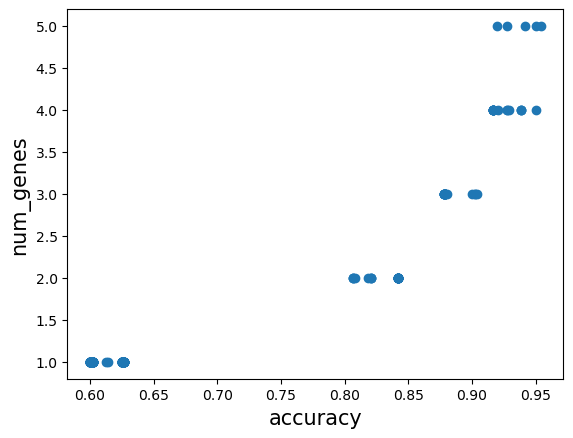

the best one is: accuracy is  0.9541666666666666 , num of genes is  5
selected genes are:  [53316.0 814266.0 471742.0 44255.0 70332.0]
the best one of generation 0 is: accuracy is  0.8527777777777779 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8527777777777779 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8527777777777779 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8652777777777778 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8652777777777778 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9152777777777779 , num of genes is  5
the b

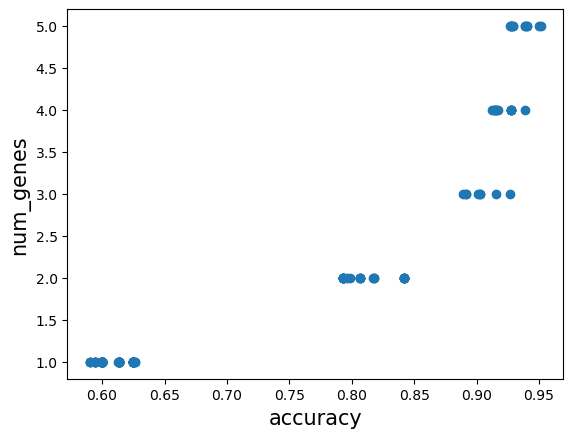

the best one is: accuracy is  0.951388888888889 , num of genes is  5
selected genes are:  [248631.0 288796.0 853687.0 461425.0 453689.0]
the best one of generation 0 is: accuracy is  0.8472222222222221 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8472222222222221 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 6 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 7 is: accuracy is  0.8944444444444445 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9055555555555556 , num of genes is  5
the best one of generation 9 is: accuracy is  0.913888888888889 , num of genes is  3
the 

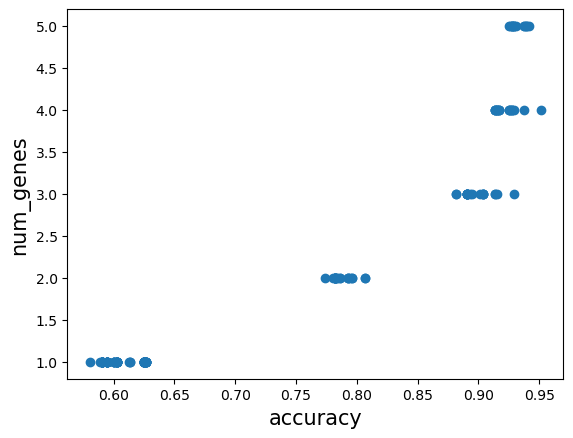

the best one is: accuracy is  0.951388888888889 , num of genes is  4
selected genes are:  [51666.0 271102.0 43338.0 345077.0]
the best one of generation 0 is: accuracy is  0.8111111111111111 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8111111111111111 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8111111111111111 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8194444444444444 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8194444444444444 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8194444444444444 , num of genes is  4
the best one of generation 6 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 9 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one o

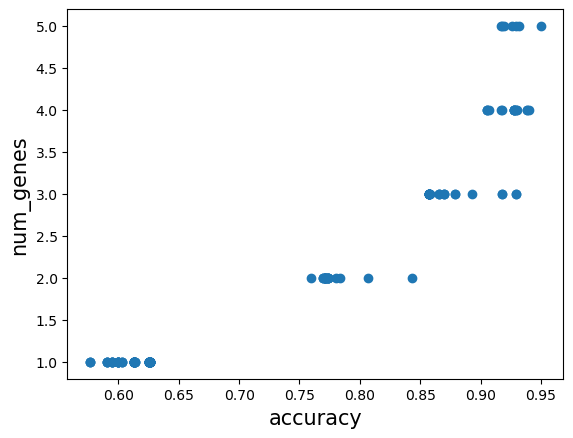

the best one is: accuracy is  0.95 , num of genes is  5
selected genes are:  [756405.0 187614.0 345232.0 307532.0 877827.0]
the best one of generation 0 is: accuracy is  0.7875 , num of genes is  5
the best one of generation 1 is: accuracy is  0.7875 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8180555555555555 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8236111111111111 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8458333333333332 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8458333333333332 , num of genes is  4
the best one of generation 6 is: accuracy is  0.8680555555555556 , num of genes is  3
the best one of generation 7 is: accuracy is  0.8777777777777779 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9263888888888889 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9263888888888889 , num of genes is  5
the best one of generation 10 is: accura

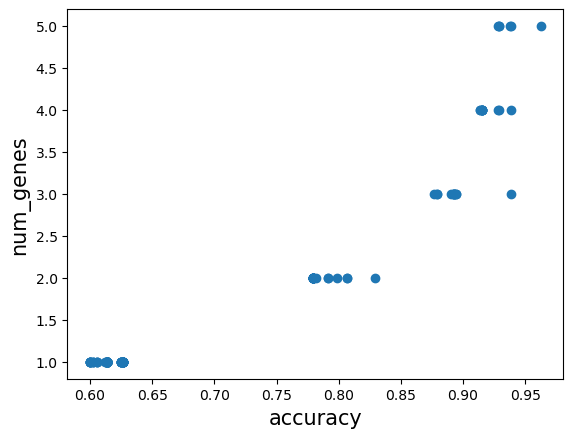

the best one is: accuracy is  0.9625 , num of genes is  5
selected genes are:  [853687.0 259579.0 502055.0 740907.0 486175.0]
the best one of generation 0 is: accuracy is  0.8666666666666666 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8666666666666666 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8819444444444444 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8819444444444444 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8819444444444444 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 9 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one o

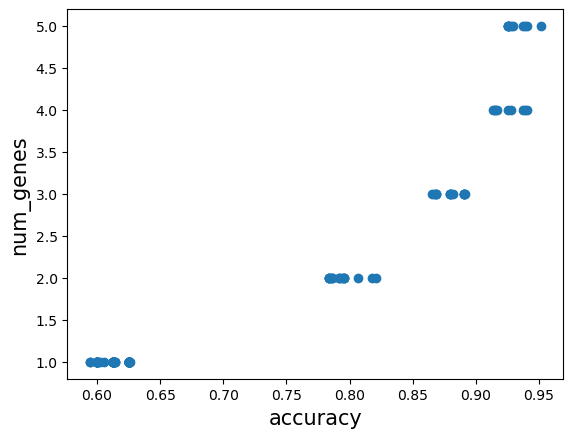

the best one is: accuracy is  0.951388888888889 , num of genes is  5
selected genes are:  [51666.0 44255.0 506032.0 882510.0 486175.0]
the best one of generation 0 is: accuracy is  0.8166666666666667 , num of genes is  5
the best one of generation 1 is: accuracy is  0.825 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8430555555555556 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8430555555555556 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8666666666666666 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8666666666666666 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8666666666666666 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 8 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9277777777777778 , num of genes is  5
the best one of ge

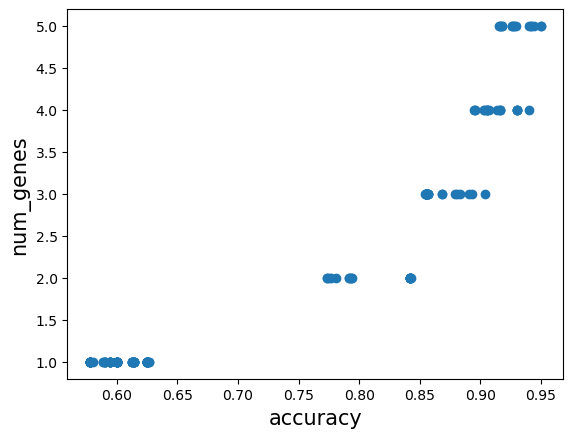

the best one is: accuracy is  0.95 , num of genes is  5
selected genes are:  [868380.0 877827.0 323603.0 490947.0 345553.0]
the best one of generation 0 is: accuracy is  0.8125 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8125 , num of genes is  3
the best one of generation 2 is: accuracy is  0.8638888888888889 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8638888888888889 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8638888888888889 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8666666666666666 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9027777777777779 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 10 is: accuracy is  0.937

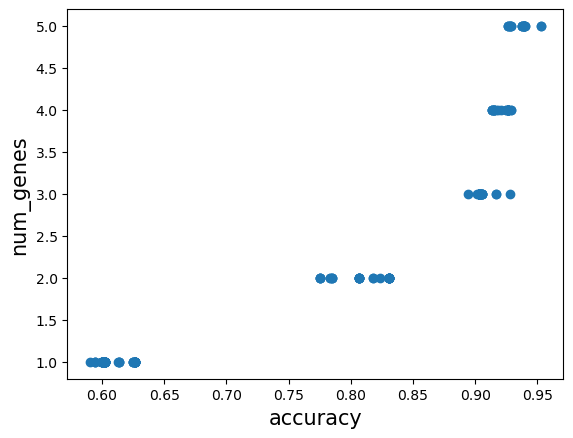

the best one is: accuracy is  0.9527777777777778 , num of genes is  5
selected genes are:  [450777.0 773301.0 853687.0 299388.0 877827.0]
the best one of generation 0 is: accuracy is  0.775 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8527777777777779 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8527777777777779 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8541666666666666 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8791666666666667 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8791666666666667 , num of genes is  3
the best one of generation 6 is: accuracy is  0.8791666666666667 , num of genes is  3
the best one of generation 7 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of generation 9 is: accuracy is  0.8902777777777778 , num of genes is  5
the best one of

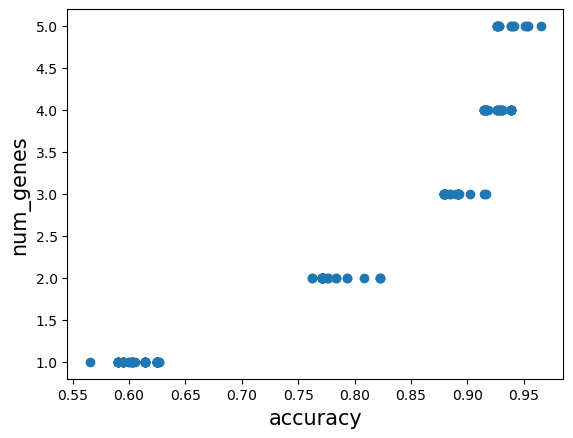

the best one is: accuracy is  0.9652777777777779 , num of genes is  5
selected genes are:  [366341.0 769959.0 756405.0 486175.0 489519.0]
the best one of generation 0 is: accuracy is  0.8388888888888889 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8388888888888889 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8388888888888889 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9041666666666666 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9527777777777778 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9527777777777778 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9527777777777778 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9527777777777778 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9527777777777778 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9527777777777778 , num of genes is  5
th

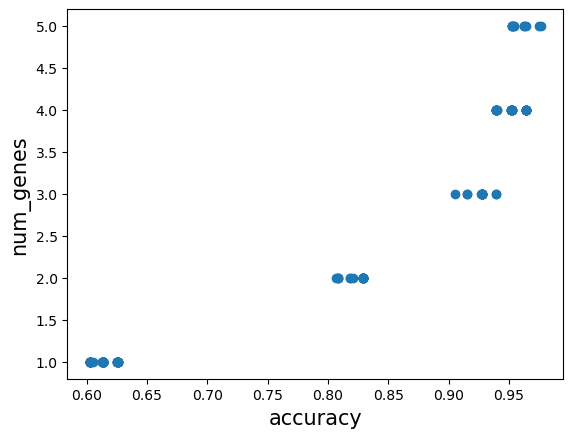

the best one is: accuracy is  0.976388888888889 , num of genes is  5
selected genes are:  [768370.0 21652.0 853687.0 25725.0 24145.0]
the best one of generation 0 is: accuracy is  0.7791666666666666 , num of genes is  5
the best one of generation 1 is: accuracy is  0.7791666666666666 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8444444444444444 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8763888888888889 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8902777777777778 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9013888888888889 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9013888888888889 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9013888888888889 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9041666666666666 , num of genes is  4
the be

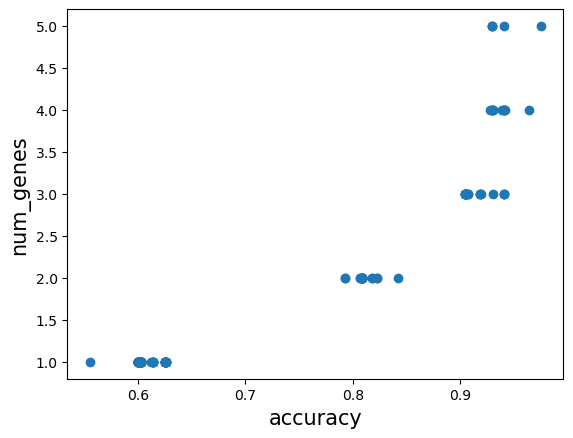

the best one is: accuracy is  0.975 , num of genes is  5
selected genes are:  [756405.0 308746.0 50117.0 853687.0 271102.0]
the best one of generation 0 is: accuracy is  0.763888888888889 , num of genes is  5
the best one of generation 1 is: accuracy is  0.7708333333333333 , num of genes is  4
the best one of generation 2 is: accuracy is  0.7958333333333334 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8527777777777779 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8541666666666666 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8541666666666666 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9013888888888889 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9013888888888889 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9013888888888889 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9152777777777779 , num of genes is  5
the best one of g

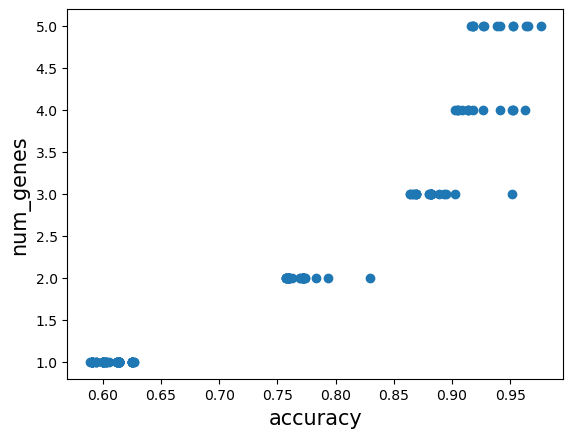

the best one is: accuracy is  0.976388888888889 , num of genes is  5
selected genes are:  [43338.0 51666.0 754649.0 486175.0 21652.0]
the best one of generation 0 is: accuracy is  0.7972222222222223 , num of genes is  5
the best one of generation 1 is: accuracy is  0.7972222222222223 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8347222222222221 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8819444444444444 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9194444444444445 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9194444444444445 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9194444444444445 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9194444444444445 , num of genes is  5
the be

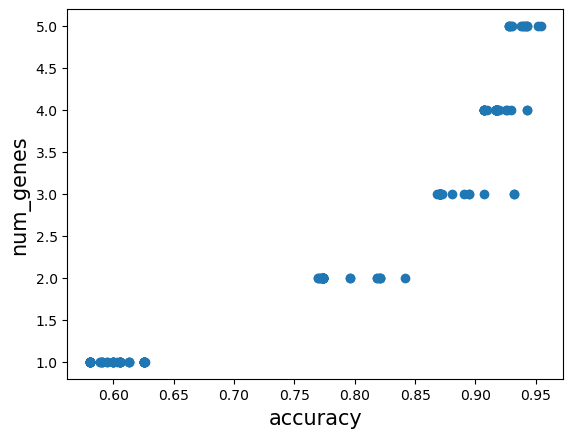

the best one is: accuracy is  0.9541666666666666 , num of genes is  5
selected genes are:  [756405.0 754085.0 1435862.0 795321.0 731648.0]
the best one of generation 0 is: accuracy is  0.7861111111111111 , num of genes is  4
the best one of generation 1 is: accuracy is  0.7861111111111111 , num of genes is  4
the best one of generation 2 is: accuracy is  0.7972222222222223 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8222222222222222 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8305555555555555 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8680555555555556 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8680555555555556 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8680555555555556 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8833333333333332 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9013888888888889 , num of genes is  5
t

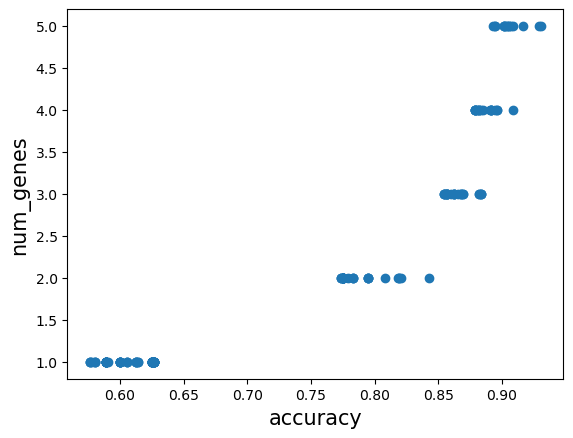

the best one is: accuracy is  0.9305555555555556 , num of genes is  5
selected genes are:  [39285.0 378502.0 47202.0 288796.0 132144.0]
the best one of generation 0 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8805555555555555 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9013888888888889 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9277777777777778 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9277777777777778 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9277777777777778 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9277777777777778 , num of genes is  4
the 

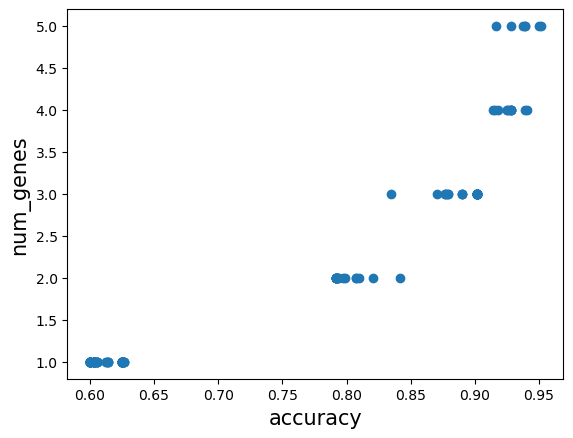

the best one is: accuracy is  0.951388888888889 , num of genes is  5
selected genes are:  [486186.0 42576.0 279790.0 853687.0 308746.0]
the best one of generation 0 is: accuracy is  0.8444444444444444 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8444444444444444 , num of genes is  3
the best one of generation 2 is: accuracy is  0.8444444444444444 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8444444444444444 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8444444444444444 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8791666666666667 , num of genes is  5
the best one of generation 9 is: accuracy is  0.8791666666666667 , num of genes is  5
the 

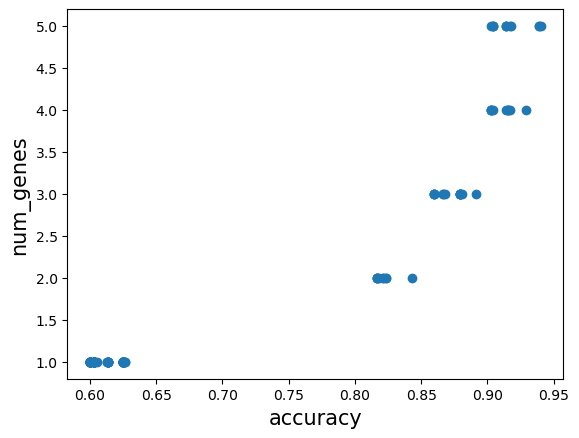

the best one is: accuracy is  0.9402777777777779 , num of genes is  5
selected genes are:  [50117.0 27549.0 745496.0 362926.0 431501.0]
the best one of generation 0 is: accuracy is  0.7722222222222223 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8583333333333332 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8583333333333332 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8583333333333332 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8666666666666666 , num of genes is  5
the best one of generation 5 is: accuracy is  0.8694444444444445 , num of genes is  5
the best one of generation 6 is: accuracy is  0.8819444444444444 , num of genes is  5
the best one of generation 7 is: accuracy is  0.8819444444444444 , num of genes is  5
the best one of generation 8 is: accuracy is  0.8819444444444444 , num of genes is  5
the best one of generation 9 is: accuracy is  0.8819444444444444 , num of genes is  5
the 

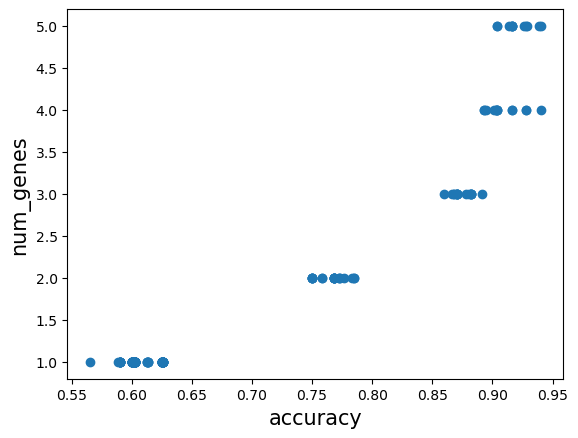

the best one is: accuracy is  0.9402777777777779 , num of genes is  4
selected genes are:  [259579.0 971367.0 856650.0 486175.0]


In [8]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=5,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1